#NLP - Group 2 - 2025.1

**Project Name:** Sport News Classifications and Recommendation System

**Group:** 2

**Members:**
- Hồng Minh Khang - 20233855
- Nguyễn Diệu My - 20233869
- Hà Huyền Thu - 20233881

**Project Overview:**


Project này sẽ xử lý hai bài toán:
- Bài toán 1 (bài toán chính): Phân loại tin tức thể thao tiếng Việt dựa trên 6 chuyên mục chính (Bóng đá, Quần vợt, Đua xe, Cờ vua, Điền kinh, Golf) với dữ liệu sử dụng từ VnExpress. Model sử dụng là Bi-LSTM.
- Bài toán 2: Đề xuất bài báo có độ tương tự cao trong cùng chuyên mục với bài toán nhập vào từ kho dữ liệu sử dụng TF-IDF và Cosine Similarity.


# Vấn đề 1: Phân loại tin tức thể thao sử dụng Bi-LSTM

**Bài toán:** Phân loại tin tức thể thao tiếng Việt (6 lớp)

**Mục tiêu**: Xây dựng mô hình phân loại tự động tin tức thể thao thành 6 chuyên mục chính:  
Bóng đá – Cờ vua – Golf – Quần vợt – Điền kinh – Đua xe  

**Input:** Văn bản tin tức tiếng Việt (title + description + content)

**Output:**
Nhãn chuyên mục tương ứng (multi-class classification)

**Quy trình tổng quát (end-to-end pipeline)**

1. Thu thập và tìm hiểu dữ liệu  
2. Làm sạch dữ liệu và Phân tích khám phá (EDA)  
3. Tiền xử lý văn bản tiếng Việt (chuẩn hóa văn bản, loại bỏ nhiễu và stopwords, tách từ bằng ViTokenizer)
4. Chia tập train / val / test (stratified)  
5. Chuyển văn bản thành số (Keras Tokenizer + Padding về độ dài cố định)  
6. Xây dựng mô hình Bi-LSTM + Attention  
7. Huấn luyện với EarlyStopping & checkpoint  
8. Đánh giá chi tiết (accuracy, F1 macro, confusion matrix, đánh giá theo từng lớp)
9. Triển khai hàm Test đơn giản  

**Metric chính mong muốn**:  
- Kỳ vọng Accuracy > 92–95% trên tập validation/test  
- Macro F1-score > 0.92 do dữ liệu khá cân bằng

**Công cụ chính**:  
- Tiền xử lý văm bản: pyvi, re, unicodedata  
- Mô hình: Keras (Bi-LSTM + Custom Attention)  
- Đánh giá: scikit-learn metrics

**Model Choice Rationale**

- Bi-LSTM:
Học được ngữ cảnh trước và sau của mỗi từ, phù hợp với văn bản dài.

- Attention:
Giúp mô hình tập trung vào các từ quan trọng trong bài báo.

- Softmax + Cross-Entropy:
Phù hợp cho bài toán phân loại đa lớp.

##1. Chuẩn bị môi trường

In [ ]:
# Cài đặt các thư viện cần thiết (chạy 1 lần là được)
!pip install chardet
!pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.6 MB/s eta 0:00:00


In [ ]:
# Import các thư viện sử dụng trong notebook
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from pyvi import ViTokenizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional,
    Dense, Dropout
)

##2. Tải Data

Sử dụng Dataset vn_sports_datasetmore.csv đã crawl về và upload lên Google Drive.


###2.1. Liên kết (Mount) với Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

###2.2. Tải Dataset đã được upload lên Google Drive

Sử dụng chardet giúp đoán chính xác encoding Tiếng Việt sử dụng trong file csv, để đọc đúng dataframe từ csv

In [ ]:
!pip install chardet

In [ ]:
import chardet

with open("/content/drive/MyDrive/vn_sports_datasetmore.csv", "rb") as f:
    raw = f.read(200000)

result = chardet.detect(raw)
print(result)


{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}


Dữ liệu sẽ được load thông qua file .csv đã được upload lên Drive

In [ ]:
import csv
# Load the dataset
df = pd.read_csv(
    "/content/drive/MyDrive/vn_sports_datasetmore.csv",
    encoding="utf-16",
    sep="\t",
    quotechar='"',
    engine="python",
    on_bad_lines='skip'
)
# Dùng utf-16 cho tiếng Việt


Preview 5 dòng đầu tiên của dữ liệu

In [ ]:
# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,category_root,title,description,content,location,url
0,Bóng đá,FIFA có thể cấm vận Malaysia bất chấp phán quy...,"LĐBĐ thế giới có thể can thiệp, thậm chí tiếp ...",Vụ bê bối nhập tịch đang khiến uy tín của Liên...,Malaysia,https://vnexpress.net/fifa-co-the-cam-van-mala...
1,Bóng đá,Việt Nam giữ ngôi đầu sau khi Arab Saudi chật ...,Chủ nhà chơi hơn người từ phút 33 nhưng phải đ...,*Ghi bàn: Rakan 88’. Sân Prince Abdullah Al Fa...,Arab Saudi,https://vnexpress.net/viet-nam-giu-ngoi-dau-sa...
2,Bóng đá,Mbappe nguy cơ lỡ Siêu Cup Tây Ban Nha,Kylian Mbappe không có tên trong đội hình Real...,"Hôm 6/1, Real công bố danh sách 24 cầu thủ bay...",NaN,https://vnexpress.net/mbappe-nguy-co-lo-sieu-c...
3,Bóng đá,Người hùng của Việt Nam: 'Cần duy trì tinh thầ...,"Hài lòng với trận ra quân thắng Jordan, nhưng ...","Không chỉ thi đấu chắc chắn ở vị trí trung vệ,...",Arab Saudi,https://vnexpress.net/nguoi-hung-cua-viet-nam-...
4,Bóng đá,Báo Indonesia 'ghen tị' khi Việt Nam thắng dễ ...,Tờ Suara Merdeka buồn khi Indonesia phải ngồi ...,Truyền thông Indonesia đồng loạt khen ngợi đoà...,NaN,https://vnexpress.net/bao-indonesia-ghen-ti-kh...


## 3. Tổng quan về Dataset

In [ ]:
# Check dataset shape
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Check data types and missing values
print("\nDataset Info:")
df.info()

The dataset has 3574 rows and 6 columns.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3574 entries, 0 to 3573
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category_root  3574 non-null   object
 1   title          3574 non-null   object
 2   description    3574 non-null   object
 3   content        3558 non-null   object
 4   location       1865 non-null   object
 5   url            3574 non-null   object
dtypes: object(6)
memory usage: 167.7+ KB


Check các bản ghi có giá trị missing và các bản ghi bị lặp lại

In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values per column:
category_root       0
title               0
description         0
content            16
location         1709
url                 0
dtype: int64

Duplicate rows:
0


Ta nhận thấy, phần lớn nội dung bị missing nằm ở cột Location, lí do là vì các bài báo trên VnExpress không bắt buộc có Location. Cột này sẽ được loại bỏ trong quá trình thực hiện.

In [ ]:
# Đếm số lượng bài theo từng chuyên mục
category_counts = df['category_root'].value_counts()

# Tạo bảng thống kê
category_table = category_counts.reset_index()
category_table.columns = ['Category', 'Number of Articles']

display(category_table)

,Category,Number of Articles
0,Golf,600
1,Quần vợt,599
2,Cờ vua,599
3,Đua xe,599
4,Điền kinh,592
5,Bóng đá,585


Số lượng các bài báo trong các chuyên mục khá cân bằng với nhau.

### Data Cleaning cơ bản

Trong bài toán này, chúng ta sẽ bỏ cột Location không liên quan đến nội dung văn bản. Đồng thời, trong tập dữ liệu tồn tại những bản ghi có giá trị rỗng ở content gây lỗi khi xử lý text, ở đây, chúng ta sẽ drop các bản ghi này đi.

In [ ]:
# Drop cột 'location' (không dùng trong bài toán)
df = df.drop(columns=['location'])

# Loại bỏ các hàng có missing value
df = df.dropna()

# Kiểm tra lại missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

# Shape sau khi làm sạch
print(f"Dataset shape after cleaning: {df.shape}")

Missing values after cleaning:
category_root    0
title            0
description      0
content          0
url              0
dtype: int64
Dataset shape after cleaning: (3558, 5)


In [ ]:
df.describe()

,category_root,title,description,content,url
count,3558,3558,3558,3558,3558
unique,6,3551,3554,3549,3555
top,Golf,Áo Vàng giải xe đạp xuyên Việt đổi chủ,Hiromu Inada trở thành triathlete cao tuổi nhấ...,Xuân Bình,https://vnexpress.net/cu-ong-92-tuoi-hoan-than...
freq,600,3,2,4,2


### EDA phân bố chuyên mục

,Category,Number of Articles
0,Golf,600
1,Cờ vua,599
2,Quần vợt,598
3,Điền kinh,590
4,Đua xe,586
5,Bóng đá,585


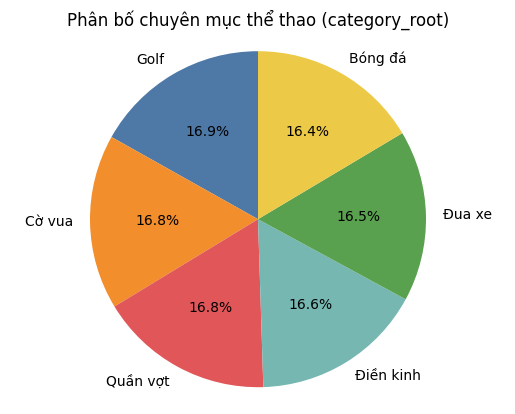

In [ ]:
# Đếm số lượng bài theo từng chuyên mục
category_counts = df['category_root'].value_counts()


# Danh sách màu
colors = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
    "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7"
]

# Tạo bảng thống kê
category_table = category_counts.reset_index()
category_table.columns = ['Category', 'Number of Articles']

display(category_table)

# Vẽ pie chart
plt.figure()
plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(category_counts)]
)
plt.title("Phân bố chuyên mục thể thao (category_root)")
plt.axis('equal')
plt.show()

**Ý nghĩa:**

- Kiểm tra sự cân bằng giữa các lớp

- Dataset tương đối cân bằng → thuận lợi cho training

##4. Data Preprocessing

### 4.1. Xử lý cột

Cột url không cần sử dụng trong bài tập này

In [ ]:
df = df[['category_root', 'title', 'description', 'content']]
df.dropna(inplace=True)

### 4.2. Ghép văn bản

Tạo cột 'text' từ việc ghép TITLE + DESCRIPTION + CONTENT, cột này sẽ được sử dụng vào Model. Việc ghép nhiều nguồn thông tin giúp tăng ngữ cảnh


In [ ]:
def cut_content(text, max_words=250):
    words = text.split()
    return " ".join(words[:max_words])

df['text'] = (
    df['title'] + ' ' +
    df['description'] + ' ' +
    df['content'].apply(lambda x: cut_content(x, 250))
)

Sau khi xử lý, ta có dữ liệu như sau:

In [ ]:
df.head()

,category_root,title,description,content,text
0,Bóng đá,FIFA có thể cấm vận Malaysia bất chấp phán quy...,"LĐBĐ thế giới có thể can thiệp, thậm chí tiếp ...",Vụ bê bối nhập tịch đang khiến uy tín của Liên...,FIFA có thể cấm vận Malaysia bất chấp phán quy...
1,Bóng đá,Việt Nam giữ ngôi đầu sau khi Arab Saudi chật ...,Chủ nhà chơi hơn người từ phút 33 nhưng phải đ...,*Ghi bàn: Rakan 88’. Sân Prince Abdullah Al Fa...,Việt Nam giữ ngôi đầu sau khi Arab Saudi chật ...
2,Bóng đá,Mbappe nguy cơ lỡ Siêu Cup Tây Ban Nha,Kylian Mbappe không có tên trong đội hình Real...,"Hôm 6/1, Real công bố danh sách 24 cầu thủ bay...",Mbappe nguy cơ lỡ Siêu Cup Tây Ban Nha Kylian ...
3,Bóng đá,Người hùng của Việt Nam: 'Cần duy trì tinh thầ...,"Hài lòng với trận ra quân thắng Jordan, nhưng ...","Không chỉ thi đấu chắc chắn ở vị trí trung vệ,...",Người hùng của Việt Nam: 'Cần duy trì tinh thầ...
4,Bóng đá,Báo Indonesia 'ghen tị' khi Việt Nam thắng dễ ...,Tờ Suara Merdeka buồn khi Indonesia phải ngồi ...,Truyền thông Indonesia đồng loạt khen ngợi đoà...,Báo Indonesia 'ghen tị' khi Việt Nam thắng dễ ...


### Encode nhãn

**Giải thích:** Neural Network chỉ xử lý được số, vậy nên các nhãn text cần được chuyển thành số nguyên. Ta sẽ chuyển các nhãn text trong cột 'category_root' thành các nhãn số nguyên trong cột 'label'

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category_root'])

num_classes = len(label_encoder.classes_)
print(label_encoder.classes_)


['Bóng đá' 'Cờ vua' 'Golf' 'Quần vợt' 'Điền kinh' 'Đua xe']


In [ ]:
df.head()

,category_root,title,description,content,text,label
0,Bóng đá,FIFA có thể cấm vận Malaysia bất chấp phán quy...,"LĐBĐ thế giới có thể can thiệp, thậm chí tiếp ...",Vụ bê bối nhập tịch đang khiến uy tín của Liên...,FIFA có thể cấm vận Malaysia bất chấp phán quy...,0
1,Bóng đá,Việt Nam giữ ngôi đầu sau khi Arab Saudi chật ...,Chủ nhà chơi hơn người từ phút 33 nhưng phải đ...,*Ghi bàn: Rakan 88’. Sân Prince Abdullah Al Fa...,Việt Nam giữ ngôi đầu sau khi Arab Saudi chật ...,0
2,Bóng đá,Mbappe nguy cơ lỡ Siêu Cup Tây Ban Nha,Kylian Mbappe không có tên trong đội hình Real...,"Hôm 6/1, Real công bố danh sách 24 cầu thủ bay...",Mbappe nguy cơ lỡ Siêu Cup Tây Ban Nha Kylian ...,0
3,Bóng đá,Người hùng của Việt Nam: 'Cần duy trì tinh thầ...,"Hài lòng với trận ra quân thắng Jordan, nhưng ...","Không chỉ thi đấu chắc chắn ở vị trí trung vệ,...",Người hùng của Việt Nam: 'Cần duy trì tinh thầ...,0
4,Bóng đá,Báo Indonesia 'ghen tị' khi Việt Nam thắng dễ ...,Tờ Suara Merdeka buồn khi Indonesia phải ngồi ...,Truyền thông Indonesia đồng loạt khen ngợi đoà...,Báo Indonesia 'ghen tị' khi Việt Nam thắng dễ ...,0


### 4.2. Data Cleaning

Trong phần này, nhóm sẽ làm sạch dữ liệu text (bỏ viết hoa, bỏ url,...). Nhóm không loại bỏ dấu tiếng Việt nhằm giữ nguyên ngữ nghĩa của văn bản.

In [ ]:
import re
import unicodedata
!pip install pyvi
from pyvi import ViTokenizer


### Từ điển Stopword và Abbreviation

Trong bài toán này, những dữ liệu liên quan đến số liệu (ngày tháng, tỉ số,...) không mang nhiều thông tin quan trọng, nên ở bước tiền xử lý này, chúng ta sẽ loại bỏ toàn bỏ thông tin về số, dấu câu, các ký tự đặc biệt.

Từ điển stopwords cơ bản đã được lọc bằng tay thay vì sử dụng thư viện có sẵn (do thư viện có sẵn có quá nhiều stopword, sau khi loại bỏ gây ảnh hưởng đến kết quả huấn luyện)

Từ điển từ viết tắt  được làm thủ công, chỉ bao gồm các từ thường được viết theo ít nhất 2 cách khác nhau trở lên (VD: HLV và huấn luyện viên), các từ viết tắt chỉ sử dụng 1 cách viết sẽ được giữ nguyên.

In [ ]:
# Stopwords cơ bản
STOPWORDS = [
    "của", "là", "những", "cái", "này", "đã", "đang", "sẽ",
    "vừa", "đều", "với", "ngay", "cho", "từ", "trong", "khi",
    "một", "các", "đó"
]

# Từ viết tắt chuyên ngành thể thao
ABBR_DICT = {
    "hlv": "huấn luyện viên",
    "vđv": "vận động viên",
    "clb": "câu lạc bộ",
    "btc": "ban tổ chức",
    "bxh": "bảng xếp hạng",
    "vck": "vòng chung kết",
    "cđv": "cổ động viên",
    "lđbđ": "liên đoàn bóng đá",
    "vđqg": "vô địch quốc gia",
    "hc": "huy chương",
    "ch": "cộng hòa",
    "đkvđ": "đương kim vô địch",
    "lđbđ": "liên đoàn bóng đá",
    "mu": "manchester united",
    "man utd": "manchester united",
    "tphcm": "thành phố hồ chí minh",
    "tp.hcm": "thành phố hồ chí minh",
    "tp hcm": "thành phố hồ chí minh"
}


**Chiến lược tiền xử lý:**
- Giữ dấu tiếng Việt
- Chuẩn hóa từ viết tắt
- Loại bỏ số, URL, ký tự đặc biệt, xuống dòng, khoảng trắng
- Loại bỏ Stopwords
- Tách từ đúng ngữ nghĩa tiếng Việt sử dụng ViTokenizer

In [ ]:
def replace_abbreviations(text):
    for abbr, full in ABBR_DICT.items():
        text = re.sub(rf"\b{abbr}\b", full, text)
    return text

def clean_vietnamese_text(text):
    # Chuẩn hóa Unicode
    text = unicodedata.normalize("NFC", text)

    # Lowercase
    text = text.lower()

    # Thay thế các từ viết tắt
    text = replace_abbreviations(text)

    # Loại bỏ URL
    text = re.sub(r"http\S+", " ", text)

    # Loại bỏ dấu câu, ký tự đặc biệt
    text = re.sub(r"[\"\'\“\”\‘\’]", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)

    # Loại bỏ số
    text = re.sub(r"\d+", " ", text)

    # Loại bỏ xuống dòng
    text = re.sub(r"\n+", " ", text)

    # Tách từ tiếng Việt sử dụng ViTokenizer
    text = ViTokenizer.tokenize(text)

    # Loại bỏ stopwords
    words = text.split()
    words = [w for w in words if w not in STOPWORDS]

    # Xóa khoảng trắng thừa
    text = " ".join(words)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df['text'] = df['text'].apply(clean_vietnamese_text)

Dữ liệu sau khi xử lý (chỉ xử lý cột text)

In [ ]:
df.head()

,category_root,title,description,content,text,label
0,Bóng đá,FIFA có thể cấm vận Malaysia bất chấp phán quy...,"LĐBĐ thế giới có thể can thiệp, thậm chí tiếp ...",Vụ bê bối nhập tịch đang khiến uy tín của Liên...,fifa có_thể cấm_vận malaysia bất_chấp phán_quy...,0
1,Bóng đá,Việt Nam giữ ngôi đầu sau khi Arab Saudi chật ...,Chủ nhà chơi hơn người từ phút 33 nhưng phải đ...,*Ghi bàn: Rakan 88’. Sân Prince Abdullah Al Fa...,việt nam giữ ngôi đầu sau arab saudi chật_vật ...,0
2,Bóng đá,Mbappe nguy cơ lỡ Siêu Cup Tây Ban Nha,Kylian Mbappe không có tên trong đội hình Real...,"Hôm 6/1, Real công bố danh sách 24 cầu thủ bay...",mbappe nguy_cơ_lỡ siêu cup tây_ban nha kylian ...,0
3,Bóng đá,Người hùng của Việt Nam: 'Cần duy trì tinh thầ...,"Hài lòng với trận ra quân thắng Jordan, nhưng ...","Không chỉ thi đấu chắc chắn ở vị trí trung vệ,...",người_hùng việt nam cần duy_trì tinh_thần như ...,0
4,Bóng đá,Báo Indonesia 'ghen tị' khi Việt Nam thắng dễ ...,Tờ Suara Merdeka buồn khi Indonesia phải ngồi ...,Truyền thông Indonesia đồng loạt khen ngợi đoà...,báo indonesia ghen_tị việt_nam thắng dễ jordan...,0


## 5. Kiểm tra Distribution của số lượng từ

Số từ text mỗi bài báo

In [ ]:
# Đếm số từ cho mỗi bài báo
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

df[['category_root', 'word_count']].head()


,category_root,word_count
0,Bóng đá,185
1,Bóng đá,224
2,Bóng đá,209
3,Bóng đá,214
4,Bóng đá,217


In [ ]:
length_stats = df.groupby('category_root')['word_count'].describe()
length_stats

,count,mean,std,min,25%,50%,75%,max
category_root,,,,,,,,
Bóng đá,585.0,206.218803,12.707052,131.0,199.0,207.0,215.0,249.0
Cờ vua,599.0,210.549249,17.495738,23.0,204.0,212.0,219.0,240.0
Golf,600.0,211.963333,13.043218,130.0,205.0,212.0,221.0,245.0
Quần vợt,598.0,202.081940,11.152137,87.0,197.0,203.0,209.0,235.0
Điền kinh,590.0,198.347458,22.940825,28.0,193.0,201.0,209.0,239.0
Đua xe,586.0,207.085324,21.794523,24.0,200.0,210.0,218.0,244.0


Kiểm tra phân bố độ dài văn bản theo chuyên mục

<Figure size 1200x600 with 0 Axes>

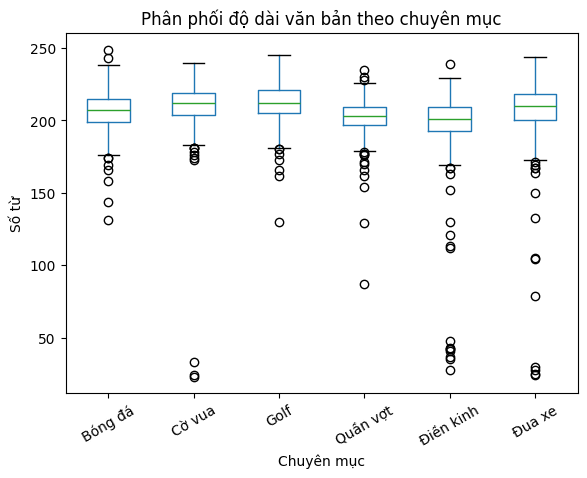

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df.boxplot(
    column='word_count',
    by='category_root',
    grid=False
)

plt.title("Phân phối độ dài văn bản theo chuyên mục")
plt.suptitle("")  # Bỏ title mặc định
plt.xlabel("Chuyên mục")
plt.ylabel("Số từ")
plt.xticks(rotation=30)
plt.show()


Các văn bản có độ dài không giống nhau, dài nhất là 249 sau token, ngắn nhất là 23.

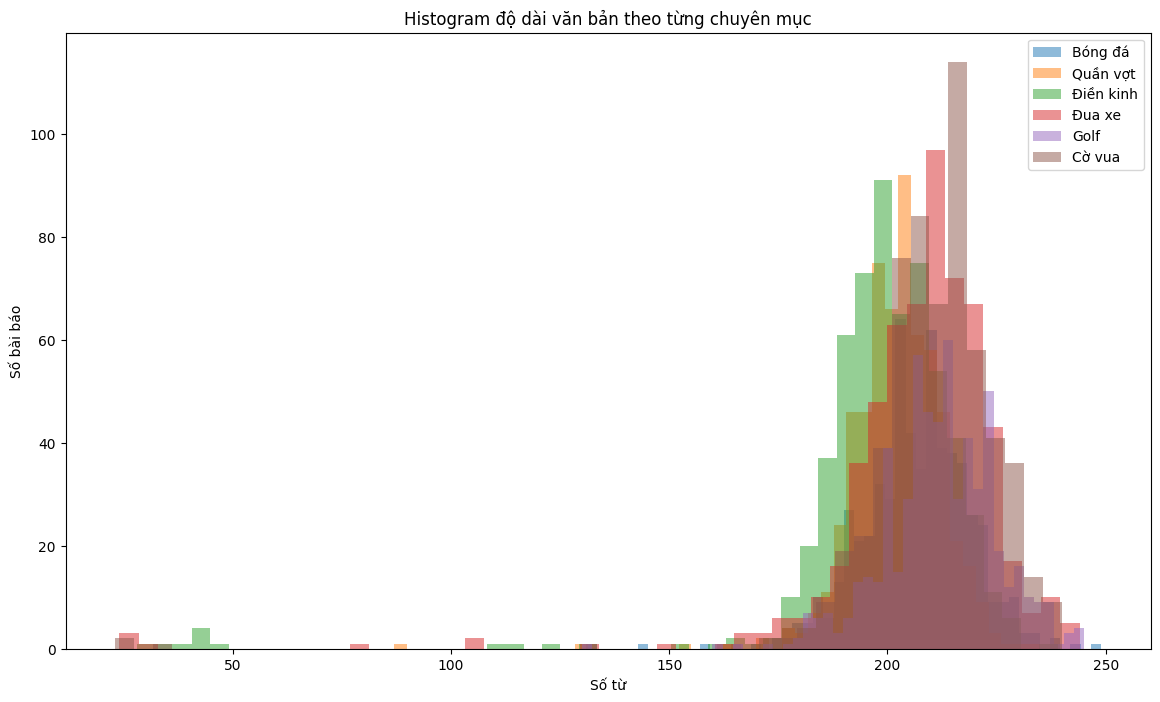

In [ ]:
labels = df['category_root'].unique()

plt.figure(figsize=(14, 8))

for label in labels:
    subset = df[df['category_root'] == label]
    plt.hist(
        subset['word_count'],
        bins=50,
        alpha=0.5,
        label=label
    )

plt.xlabel("Số từ")
plt.ylabel("Số bài báo")
plt.title("Histogram độ dài văn bản theo từng chuyên mục")
plt.legend()
plt.show()


Tải về Ready-to-train Dataset

In [ ]:
df_ready = df[['text', 'label']]
df_ready.to_csv(
    "vn_sports_ready_to_train.csv",
    index=False,
    encoding="utf-16"
)

## 6. Train/Test Split

Dữ liệu train / test sẽ được chia 0.8 / 0.2 theo từng label

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']   # Stratified split đảm bảo tỷ lệ 6 lớp được giữ nguyên giữa tập huấn luyện và kiểm tra.
)

## 7. Tokenization & Padding

### 7.1. Import thư viện và set thông số cần thiết

 (không cần nếu đã import ở đầu bài)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
MAX_VOCAB = 30000   # set số lượng từ vựng tối đa
MAX_LEN = 250 # độ dài tối đa

### 7.2. Tokenizer

Tokenization bằng Keras Tokenizer

Sau khi đã tách từ đúng, mô hình học máy không thể xử lý trực tiếp văn bản mà cần chuyển thành dạng số.

Ở đây, Tokenizer của Keras được sử dụng để xây dựng từ điển (vocabulary) và ánh xạ mỗi token (từ) thành một số nguyên

In [ ]:
tokenizer = Tokenizer(
    num_words=MAX_VOCAB,
    oov_token="<OOV>",
    filters='!"#$%&()*+,-./:;<=>?@[\\]^`{|}~'  # bỏ dấu _
)
# giới hạn số lượng từ max trong vocab
# các từ không nằm trong vocab sẽ là <oov>
# nếu không bỏ dấu _ trong filter thì tokenizer keras sẽ bỏ luôn dấu _ đi, khiến nó mất đi VNTokenization trước đo

tokenizer.fit_on_texts(X_train)
# đếm tần suất xuất hiện của từng token và gán index dựa theo tần suất (càng xuất hiện nhiều index càng nhỏ)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

In [ ]:
# Lấy word index (để chuyển từ 'từ' sang 'số')
word_index = tokenizer.word_index

# In 20 từ đầu tiên
for i, (word, idx) in enumerate(word_index.items()):
    if i >= 20:
        break
    print(f"{word:20s} -> {idx}")


<OOV>                -> 1
và                   -> 2
ở                    -> 3
sau                  -> 4
hai                  -> 5
được                 -> 6
không                -> 7
anh                  -> 8
có                   -> 9
năm                  -> 10
giải                 -> 11
tại                  -> 12
để                   -> 13
vào                  -> 14
nhưng                -> 15
người                -> 16
về                   -> 17
nhất                 -> 18
trên                 -> 19
thứ                  -> 20


Kiểm tra tokenizer

In [ ]:
sample_text = X_train[0]
print("Original text:")
print(sample_text)

sequence = tokenizer.texts_to_sequences([sample_text])

token_ids = sequence[0]

print("Token IDs:")
print(token_ids)

print("Number of tokens:", len(token_ids))

index_word = tokenizer.index_word

tokens = [index_word.get(i, "<UNK>") for i in token_ids]

print("Tokens:")
print(tokens)

Original text:
fifa có_thể cấm_vận malaysia bất_chấp phán_quyết tòa quốc_tế liên_đoàn bóng_đá thế_giới có_thể can_thiệp thậm_chí tiếp_quản liên_đoàn bóng_đá malaysia để khôi_phục hệ_thống sau vụ gian_lận cầu_thủ nhập_tịch vụ bê_bối nhập_tịch khiến uy_tín liên_đoàn bóng_đá malaysia fam bị ảnh_hưởng nghiêm_trọng sau hai lần khiếu_nại bất_thành ở cấp fifa họ kháng_cáo lên tòa trọng_tài thể_thao cas cũng hy_vọng cuối_cùng để lật_ngược tình_thế theo truyền_thông malaysia diễn_biến được liên_đoàn bóng_đá thế_giới fifa và liên_đoàn bóng_đá châu á afc theo_dõi sát_sao tổ_chức có_thể can_thiệp sâu hơn vào nội_bộ fam nếu nhận thấy liên_đoàn thành_viên không_thể giải_quyết được cuộc khủng_hoảng bất_kể phán_quyết cas có lợi fam hay không fifa và afc có quyền tạm_thời tiếp_quản liên_đoàn để khôi_phục hệ_thống kênh truyền_hình malaysiaastro arenađưa tin ngày kênh liên_hệ tổng_thư_ký afc windsor paul john và nhận được hai kịch_bản thứ nhất được miêu_tả không ai mong_muốn ban lãnh_đạo fam hiện_tại bị 

### 7.3. Padding

Neural Network (BiLSTM, CNN, Transformer…) yêu cầu tất cả input phải có cùng độ dài, vậy nên ta cần Padding để chúng có cùng độ dài.

In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded = pad_sequences(
    sequence,
    maxlen=MAX_LEN,
    padding='post'
)
# độ dài tối đa là 250

print("Padded sequence:")
print(padded)


Padded sequence:
[[  416    91 10441   476  1385  2355  1714   474   333   281    28    91
   2176   524  6994   333   281   476    13  6428   391     4   728  1083
    160  1014   728  3593  1014   116  2190   333   281   476   895    43
    632  1089     4     5    27  1800  2234     3   748   416   131  1852
     53  1714   339   258  1880    30   552   364    13  2142  1457    58
    845   476  1609     6   333   281    28   416     2   333   281   145
    201  1344  1126  5785   132    91  2176   810    32    14  1969   895
    140   165   192   333   464   224  2635     6    72  2557  2838  2355
   1880     9   931   895   178     7   416     2  1344     9   643  3064
   6994   333    13  6428   391  1854   769 20210 20211   451    42  1854
   3379  2894  1344  7433  1456  1629     2   165     6     5  1516    20
     18     6  4549     7   421  1820   240  1525   895   633    43 20212
      9  2607     4   416   248  1344  1313  1623  3064  1157     9  2066
    636 11091  2920  

## 8. Model

### 8.1. Import library

In [ ]:
# Có thể bỏ qua nếu đã import từ đầu
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

### 8.2. Model Parameters

Trong bài toán này, Attention Layer được xây dựng dựa trên công thức (1) trong bài tham khảo, xây dựng thủ công dựa trên cơ chế additive attention (Bahdanau attention). So với các lớp attention có sẵn trong Keras, cách tiếp cận này cho phép kiểm soát trực tiếp quá trình tính trọng số và dễ dàng trình bày các bước toán học, từ đó phù hợp hơn cho mục đích học tập.

In [ ]:
class CustomAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        # Gọi constructor của lớp cha (Layer) để khởi tạo layer tùy chỉnh
        super(CustomAttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # Ma trận trọng số W_u dùng để biến đổi hidden states h_it
        self.W_u = self.add_weight(
            name="W_u",
            shape=(input_shape[-1], input_shape[-1]),  # input (batchsz, timesteps, hiddendim)-> [-1] chỉ lấy hiddendim = 128
            initializer='glorot_uniform', # khởi tạo trọng số, lấy ngẫu nhiên phân phối đều
            trainable=True # cho phép trọng số này cập nhật trong quá trình huấn luyện
        )

        # Bias vector b_u cho phép dịch chuyển kết quả tuyến tính
        self.b_u = self.add_weight(
            name="b_u",
            shape=(input_shape[-1],),  # (hidden_dim,)
            initializer='zeros',
            trainable=True
        )

        # Vector ngữ cảnh (context vector) u_in dùng để tính attention score
        self.u_in = self.add_weight(
            name="u_in",
            shape=(input_shape[-1],),  # (hidden_dim,)
            initializer='glorot_uniform',
            trainable=True
        )

        # Gọi build của lớp cha để hoàn tất quá trình khởi tạo
        super(CustomAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        """
        inputs: tensor shape (batch_size, time_steps, hidden_dim)
        """
        # Trong đó:
        # batch_size: số mẫu trong một batch = 64 (xử lí 64 câu 1 lúc)
        # time_steps: số token trong câu (ở đây đã được chuẩn hóa MAX_LEN=250)
        # hidden_dim: kích thước vector hidden state của Bi-LSTM = 128 (2 chiều được concat với nhau)

        # Bước 1: Tính u_it = tanh(W_u * h_it + b_u)
        # Áp dụng phép biến đổi tuyến tính + phi tuyến cho mỗi hidden state
        u_it = tf.tanh(tf.matmul(inputs, self.W_u) + self.b_u)

        # Bước 2: Tính attention score: v_it = u_it^T * u_in
        # Đây là phép tích vô hướng giữa u_it và vector ngữ cảnh u_in
        vu = tf.reduce_sum(u_it * self.u_in, axis=-1)  # shape: (batch_size, time_steps)

        # Bước 3: Chuẩn hóa các score bằng softmax để thu được trọng số attention α_it
        alpha = tf.nn.softmax(vu, axis=1)  # shape: (batch_size, time_steps)

        # Bước 4: Tính vector ngữ cảnh (context vector)
        # s = Σ (α_it * h_it)
        context = tf.reduce_sum(inputs * tf.expand_dims(alpha, axis=-1), axis=1)
        # shape: (batch_size, hidden_dim)

        return context

BUILD MODEL TỪ SCRATCH (Functional API)

Mô hình được xây dựng từ đầu bằng Keras Functional API, cho phép thiết kế linh hoạt các lớp như Embedding, Bi-LSTM và Attention. Việc xây dựng from scratch giúp mô hình học trực tiếp từ dữ liệu của bài toán, không phụ thuộc vào các mô hình pretrained, đồng thời dễ dàng mở rộng và điều chỉnh kiến trúc theo yêu cầu nghiên cứu.

In [ ]:
embedding_dim = 200      # Kích thước vector embedding cho mỗi từ
lstm_units = 64         # Số units cho mỗi chiều của Bi-LSTM → concat = 128
dropout_rate = 0.5      # Tỷ lệ dropout để giảm overfitting
l2_reg = 0.01           # Hệ số regularization L2 cho Dense layer cuối


# INPUT LAYER

# Đầu vào là chuỗi token có độ dài cố định MAX_LEN
inputs = Input(shape=(MAX_LEN,))


# EMBEDDING LAYER

# Chuyển mỗi token thành vector embedding học được
embedded = Embedding(
    input_dim=len(tokenizer.word_index) + 1,  # Kích thước từ điển = số token + 1 để chứa cả token 0
    output_dim=embedding_dim                  # Kích thước vector embedding = 200
)(inputs)


# BI-DIRECTIONAL LSTM

# Bi-LSTM tự động gồm LSTM xuôi + LSTM ngược
# return_sequences=True để trả về hidden state tại mỗi timestep (phục vụ Attention)
bi_lstm_out = Bidirectional(
    LSTM(
        units=lstm_units,   #Số units cho mỗi chiều của Bi-LSTM → concat = 128
                            #concat- Số units cho mỗi chiều của Bi-LSTM nối 2 chiều lại : 64 (chiều đi) + 64 (chiều về) = 128
        return_sequences=True,
        dropout=dropout_rate  # tắt ngẫu nhiên 50% neuron ở mỗi batch khi training-> tránh overfiting
    )
)(embedded)


# ATTENTION LAYER

# Áp dụng Custom Attention đã được định nghĩa
attention_out = CustomAttentionLayer()(bi_lstm_out)


# CLASSIFICATION HEAD

# Dropout để giảm overfitting
dropped = Dropout(dropout_rate)(attention_out) # 50% giá trị trong vector attention sẽ được đặt về 0 ở mỗi batch khi train

# Dense layer với softmax cho phân loại nhiều lớp
# kernel_regularizer=l2(l2_reg) để tránh overfitting
outputs = Dense(
    num_classes,
    activation='softmax',
    kernel_regularizer=regularizers.l2(l2_reg)
)(dropped)


# BUILD MODEL

model = Model(inputs=inputs, outputs=outputs)


### 8.3. Compile

Bi-LSTM cho phép mô hình học ngữ cảnh theo cả hai chiều trước–sau của chuỗi văn bản, phù hợp với bài toán phân loại văn bản dài.

Import thư viện (bỏ qua nếu đã tồn tại)

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Learning rate = 0.001 như bài báo
    loss='sparse_categorical_crossentropy',  # Loss cross-entropy cho softmax multi-class
    metrics=['accuracy']  # Theo dõi accuracy
)

### 8.4. Model Training

Trong quá trình huấn luyện mô hình, để tránh hiện tượng overfitting và đảm bảo hiệu quả học tập, hai cơ chế điều khiển quá trình học được áp dụng: Early Stopping và Model Checkpoint.

In [ ]:
# Dừng huấn luyện sớm nếu val_loss không cải thiện sau 3 epoch
# restore_best_weights=True giúp khôi phục trọng số tốt nhất (epoch có val_loss thấp nhất)
early_stopping = EarlyStopping(
    monitor='val_loss',          # Theo dõi loss trên tập validation
    patience=3,                 # Chờ 3 epoch trước khi dừng
    restore_best_weights=True,  # Khôi phục trọng số tốt nhất
    verbose=1                   # In thông báo khi callback được kích hoạt
)


# MODEL CHECKPOINT CALLBACK

# Lưu model tốt nhất dựa trên val_loss vào Google Drive
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_model.keras',  # Đường dẫn lưu model tốt nhất
    monitor='val_loss',                         # Theo dõi loss trên validation
    save_best_only=True,                        # Chỉ lưu model khi có cải thiện
    mode='min',                                # Mục tiêu là giảm val_loss
    verbose=1                                  # In thông báo khi lưu model
)


# MODEL TRAINING

# Huấn luyện model với callback để tránh overfitting và lưu model tốt nhất
history = model.fit(
    X_train_pad,                               # Dữ liệu huấn luyện
    y_train,                                   # Nhãn huấn luyện
    validation_data=(X_val_pad, y_val),         # Dữ liệu validation
    epochs=10,                                 # Số epoch huấn luyện (theo bài báo)
    batch_size=64,                             # Batch size (điều chỉnh từ 32 → 64)
    callbacks=[early_stopping, checkpoint],     # Thêm callback early stopping + checkpoint
    verbose=1                                  # Hiển thị chi tiết mỗi epoch
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4276 - loss: 1.7265
Epoch 1: val_loss improved from inf to 0.51697, saving model to /content/drive/MyDrive/best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.4319 - loss: 1.7188 - val_accuracy: 0.9508 - val_loss: 0.5170
Epoch 2/10
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9552 - loss: 0.4217
Epoch 2: val_loss improved from 0.51697 to 0.22182, saving model to /content/drive/MyDrive/best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9559 - loss: 0.4168 - val_accuracy: 0.9789 - val_loss: 0.2218
Epoch 3/10
43/45 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9891 - loss: 0.1869
Epoch 3: val_loss improved from 0.22182 to 0.20138, saving model to /content/drive/MyDrive/best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9890 - loss: 0.1872 - val_accuracy: 0.9719 - val_loss: 0.2014
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9821 - los

In [ ]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 250, 200)       │     4,056,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 250, 128)       │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_attention_layer          │ (None, 128)            │        16,640 │
│ (CustomAttentionLayer)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,629,084 (48.18 MB)

 Trainable params: 4,209,694 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,419,390 (32.12 MB)

In [ ]:
last_layer = model.layers[-1]
print(last_layer)


<Dense name=dense, built=True>


In [ ]:
print("Tên layer:", last_layer.name)
print("Loại layer:", type(last_layer))
print("Số neuron:", last_layer.units)
print("Activation:", last_layer.activation)


Tên layer: dense
Loại layer: <class 'keras.src.layers.core.dense.Dense'>
Số neuron: 6
Activation: <function softmax at 0x7b03c363aa20>


## 9. Evaluation


Phần này đánh giá hiệu quả của mô hình Bi-LSTM + Attention trên tập validation, sử dụng nhiều chỉ số khác nhau nhằm phản ánh toàn diện khả năng phân loại của mô hình.

In [ ]:
import numpy as np

# Dự đoán xác suất
y_pred_prob = model.predict(X_val_pad)

# Lấy nhãn dự đoán (argmax)
y_pred = np.argmax(y_pred_prob, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


**Giải thích:**


*   y_pred_prob: Ma trận xác suất đầu ra của mô hình, mỗi dòng tương ứng với một bài báo, mỗi cột là xác suất thuộc về một trong 6 chuyên mục.
*   argmax(axis=1):
Chọn nhãn có xác suất cao nhất làm nhãn dự đoán cuối cùng.


###Accuracy (Độ chính xác tổng thể)

**Ý nghĩa:**

Accuracy là tỷ lệ số bài báo được phân loại đúng trên tổng số bài báo trong tập validation. (số mẫu dữ đoán đúng / tổng số mẫu)

Nhận xét: Accuracy cao cho thấy mô hình hoạt động tốt trên toàn bộ tập dữ liệu.Tuy nhiên, Accuracy không phản ánh đầy đủ khi đánh giá chi tiết từng lớp mà cần thêm Precision, Recall, F1.

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_val, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9887640449438202


###Classification Report (Precision – Recall – F1-score)

Các chỉ số:




* Precision (Độ chính xác theo dự đoán), chỉ số này cho biết trong các bài được dự đoán là lớp X, bao nhiêu bài là đúng? Khi Precision cao tức là ít dự đoán nhầm sang lớp đó.

* Recall (Khả năng bao phủ), chỉ số này cho biết tất cả các bài thực sự thuộc lớp X, mô hình dự đoán đúng được bao nhiêu? Khi Recall cao nghĩa là ít bỏ sót bài thuộc lớp đó.

* F1-score là một chỉ số trung bình điều hòa giữa Precision và Recall. Có thể nói, đây là chỉ số quan trọng nhất trong đánh giá mô hình phân loại.

* Support: Số lượng mẫu thực tế của từng lớp trong tập validation.

Classification Report cho phép đánh giá hiệu quả chi tiết trên từng chuyên mục.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_val,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9828    0.9744    0.9785       117
           1     1.0000    1.0000    1.0000       120
           2     0.9836    1.0000    0.9917       120
           3     0.9917    1.0000    0.9959       120
           4     0.9832    0.9915    0.9873       118
           5     0.9912    0.9658    0.9784       117

    accuracy                         0.9888       712
   macro avg     0.9888    0.9886    0.9886       712
weighted avg     0.9888    0.9888    0.9887       712



In [ ]:
from sklearn.metrics import precision_recall_fscore_support

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_val, y_pred, average='macro'
)

print("Macro Precision:", p_macro)
print("Macro Recall:", r_macro)
print("Macro F1:", f1_macro)

### Confusion Matrix

Confusion Matrix theo số lượng bài

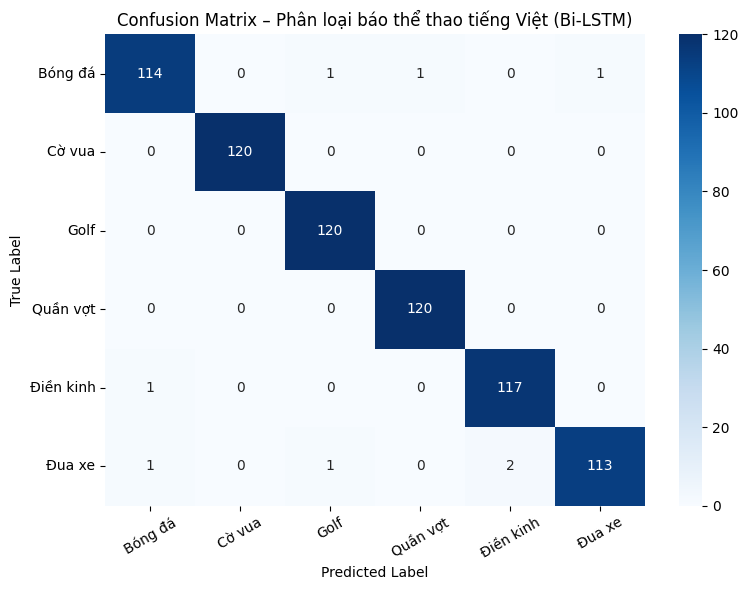

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Danh sách label theo đúng thứ tự encode
label_names = [
    'Bóng đá',
    'Cờ vua',
    'Golf',
    'Quần vợt',
    'Điền kinh',
    'Đua xe'
]

# Tính confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Vẽ confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Phân loại báo thể thao tiếng Việt (Bi-LSTM)")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Confusion Matrix theo phần trăm

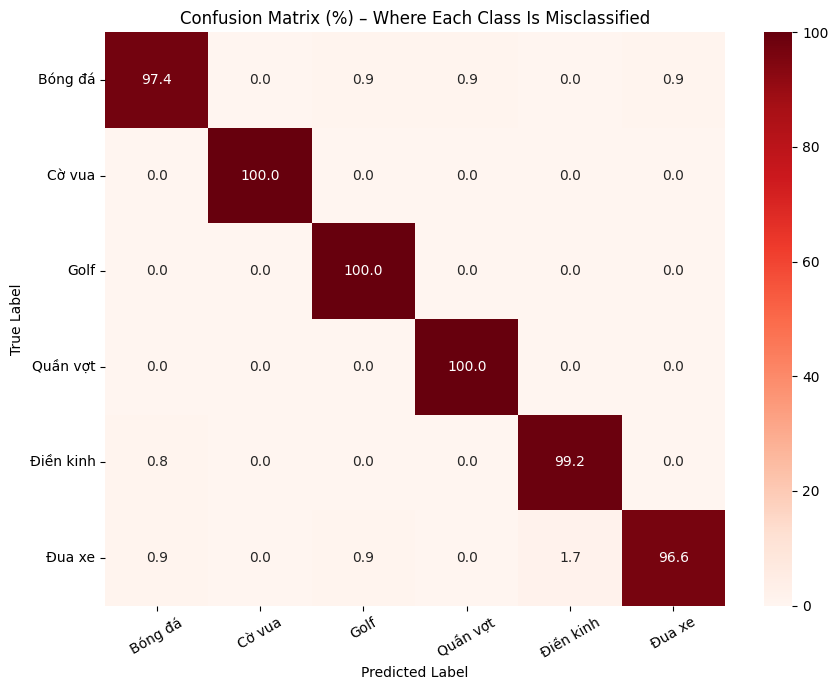

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tính confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Chuẩn hóa theo TRUE label (theo hàng)
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (%) – Where Each Class Is Misclassified")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Accuracy trên từng lớp

In [ ]:
import numpy as np
import pandas as pd

# Confusion matrix đã có
cm = confusion_matrix(y_val, y_pred)

# Accuracy theo từng lớp = diagonal / tổng hàng
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Tạo DataFrame cho đẹp
df_class_acc = pd.DataFrame({
    "Category": label_names,
    "Accuracy": class_accuracy
})

df_class_acc


,Category,Accuracy
0,Bóng đá,0.974359
1,Cờ vua,1.000000
2,Golf,1.000000
3,Quần vợt,1.000000
4,Điền kinh,0.991525
5,Đua xe,0.965812


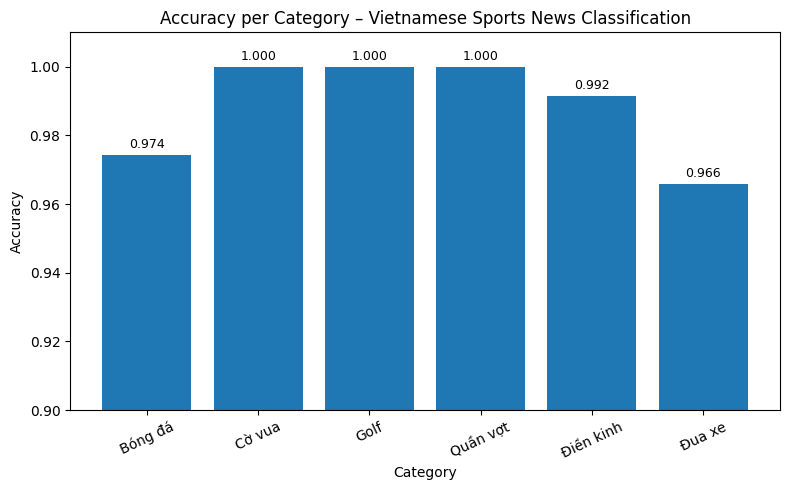

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(df_class_acc["Category"], df_class_acc["Accuracy"])

plt.ylim(0.9, 1.01)
plt.ylabel("Accuracy")
plt.xlabel("Category")
plt.title("Accuracy per Category – Vietnamese Sports News Classification")

for i, v in enumerate(df_class_acc["Accuracy"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=9)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## 10. Testing

### 10.1. Hàm test (predict_category)

Hàm predict_catgory(text) sẽ nhận vào một đoạn text, sau đó trả về label và confidence score của đoạn text đã nhập.

In [ ]:
import numpy as np

def predict_category(text, return_confidence=False):
    """
    Dự đoán category cho một đoạn text tin tức thể thao tiếng Việt.

    Args:
        text (str): Nội dung text cần phân loại.
        return_confidence (bool): Nếu True, trả về cả label và confidence score.

    Returns:
        str: Tên category (ví dụ: 'Bóng đá')
        hoặc tuple (str, float): (category, confidence) nếu return_confidence=True
    """
    if not isinstance(text, str) or not text.strip():
        if return_confidence:
            return "Không xác định", 0.0
        return "Không xác định"

    # Tiền xử lý (giả sử hàm clean_vietnamese_text đã có trong notebook)
    text = clean_vietnamese_text(text)

    # Tokenize & pad (giống training)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict (verbose=0 để không in log thừa)
    pred = model.predict(pad, verbose=0)
    confidence = np.max(pred)  # Độ tin cậy cao nhất
    label_idx = np.argmax(pred)
    category = label_encoder.inverse_transform([label_idx])[0]

    if return_confidence:
        return category, round(confidence, 4)
    return category

### 10.2. Input Text Form

In [ ]:
# Ví dụ sử dụng (sửa lỗi chuỗi đa dòng bằng triple quotes)
text = """

"""

print("Category dự đoán:", predict_category(text))

# Với confidence
cat, conf = predict_category(text, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Không xác định
Category: Không xác định (Confidence: 0.0000)


### 10.3. Examples

In [ ]:
# Ví dụ sử dụng (sửa lỗi chuỗi đa dòng bằng triple quotes)
text = """
2
Marathon
Thứ hai, 12/1/2026, 09:40 (GMT+7)
Hiểu và duy trì động lực chạy bộ để không bỏ cuộc
Chạy bộ dễ bắt đầu nhưng khó duy trì, khi nhiều người bỏ cuộc sớm không phải vì thể lực mà do thiếu động lực và cách tiếp cận đúng.

Về mặt lý thuyết, chạy bộ là một trong những môn thể thao đơn giản nhất. Chỉ cần một đôi giày phù hợp và vài phút rảnh rỗi, bất kỳ ai cũng có thể bắt đầu. Tuy nhiên, khoảng cách từ ý định đến hành động lại thường bị ngăn cách bởi những rào cản vô hình. Thực tế, các nghiên cứu theo dõi người chạy mới cho thấy khoảng 29,5% người tham gia bỏ cuộc chỉ trong 26 tuần đầu.

Theo nghiên cứu từ Trung tâm Y tế Đại học Erasmus (Hà Lan), chấn thương là nguyên nhân hàng đầu khiến 48% người mới chạy bộ dừng lại. Ở khía cạnh hành vi, báo cáo trên tạp chí của Đại học Y học Thể thao Mỹ (ACSM) chỉ ra 40% người tham gia từ bỏ vì thiếu thời gian. Nghiên cứu này cũng nhấn mạnh giai đoạn "chạy đà" là nhạy cảm nhất, khi 67% các quyết định bỏ cuộc diễn ra lúc người tập còn chưa kịp đạt đến cường độ mục tiêu.
"""

print("Category dự đoán:", predict_category(text))

# Với confidence
cat, conf = predict_category(text, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Điền kinh
Category: Điền kinh (Confidence: 0.9847)


In [ ]:
# Ví dụ sử dụng (sửa lỗi chuỗi đa dòng bằng triple quotes)
text = """
Diễn viên Trung Quốc lao đao vì 'than nghèo kể khổ'
Diễn viên Trung Quốc lao đao vì 'than nghèo kể khổ'
Diễn viên Diêm Học Tinh mất hợp đồng quảng cáo, phải viết thư xin lỗi khán giả sau khi than vãn thu nhập thấp, khó khăn.

Theo Guancha, khi livestream trên nền tảng Douyin, Diêm Học Tinh tiết lộ con trai của cô - Lâm Ngạo Phi - theo nghiệp diễn, thù lao một phim là "vài trăm nghìn nhân dân tệ" và mỗi năm chỉ có một phim. Con dâu cô là diễn viên nhà hát kịch sân khấu, thu nhập "còn thấp hơn", đôi vợ chồng đã có em bé.

Theo Diêm Học Tinh, chi phí vận hành đại gia đình mỗi năm là 1,8 triệu tệ (6,7 tỷ đồng). Cô cảm thấy vợ chồng con trai kiên trì được là "việc vô cùng khó khăn, vất vả". Con trai cô chịu áp lực lớn trong lĩnh vực phim truyền hình, hiện anh có "lối thoát" là đến trường quay Hoành Điếm ở tỉnh Chiết Giang tìm kiếm thêm cơ hội diễn xuất.


"""

print("Category dự đoán:", predict_category(text))

# Với confidence
cat, conf = predict_category(text, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Golf
Category: Golf (Confidence: 0.5799)


In [ ]:
sample_text = """
Kỳ thủ 16 tuổi trở thành Kiện tướng Quốc tế
Kỳ thủ 16 tuổi trở thành Kiện tướng Quốc tế
9
Hà NộiKỳ thủ cờ vua 16 tuổi Đinh Nho Kiệt giành chuẩn Kiện tướng Quốc tế thứ ba tại giải Đại kiện tướng Hà Nội, đủ điều kiện phong danh hiệu này.

Ở vòng 9, cũng là vòng cuối của giải sáng nay 5/1, Nho Kiệt hòa Kiện tướng Quốc tế (IM) Ấn Độ Ravi Teja. Kết quả đó vừa đủ giúp kỳ thủ 16 tuổi đạt 5,5 điểm sau 9 ván. Hiệu suất thi đấu của anh đạt 2.474 hệ số, vượt mức 2.450 cần thiết để giành chuẩn IM.

Đinh Nho Kiệt tại giải cờ vua Đại kiện tướng Quốc tế Hà Nội, ở phường Bạch Mai, tháng 1/2026. Ảnh: Bùi Vinh
Đinh Nho Kiệt tại giải cờ vua Đại kiện tướng Quốc tế Hà Nội, ở phường Bạch Mai, tháng 1/2026. Ảnh: Bùi Vinh

Trong 9 ván, Nho Kiệt thắng Đại kiện tướng (GM) Từ Hoàng Thông, IM Lee Jun-hyeok, Laohawirapap Prin, hòa GM John Paul Gomez, Daniel Quizon, IM Wynn Zaw Htun, Ravi, FM Alexander Chernyavsky, chỉ thua một ván trước IM Phạm Trần Gia Phúc. Tổng cộng, Nho Kiệt kiếm 18,4 Elo, nâng Elo tức thời lên 2.344,4.

Đây là chuẩn thứ ba, cũng là chuẩn cuối cùng của Nho Kiệt. Trước đó, kỳ thủ này giành hai chuẩn, lần lượt tại giải Đại kiện tướng Quốc tế Quảng Ninh tháng 5/2024, và giải Singapore Mở rộng tháng 12/2024. Nho Kiệt cũng từng vượt mốc Elo 2.400, khi có Elo cao 2.404 tháng 6/2024.

Quảng cáo

Trong những kỳ thủ dưới 20 tuổi của Việt Nam hiện tại, Nho Kiệt là người thứ tư được phong IM, sau Đầu Khương Duy, Gia Phúc và Bành Gia Huy. Khương Duy chạm mốc này năm 2024, khi mới 13 tuổi."""

print("Category dự đoán:", predict_category(sample_text))

# Với confidence
cat, conf = predict_category(sample_text, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")


Category dự đoán: Cờ vua
Category: Cờ vua (Confidence: 0.9936)


In [ ]:
st2 = """Chelsea giật điểm từ Man City ở phút bù
AnhTiền vệ Enzo Fernandez ghi bàn ở phút bù, giúp Chelsea hòa chủ nhà Man City 1-1 ở vòng 20 Ngoại hạng Anh hôm 4/1.

Man CityChelsea
Thứ hai, ngày 5/1/2026, 00:30
Ngoại hạng Anh - Vòng 20
Kết thúc
Man City
Man City
1 - 1
Hiệp một: 1-0
Chelsea
Chelsea
icon-ball
T. Reijnders (42')
E. Fernandez (90+4')
icon-ball
Chi tiết trận đấu
Đây được xem như thời điểm thuận lợi nhất để Man City đối đầu Chelsea. Đội bóng London sụp đổ trong tháng 12 vừa qua với phong độ tệ hại ở Ngoại hạng Anh, dẫn đến sự thay đổi HLV ngay ngày đầu năm mới.

Tuy nhiên, chủ nhà không tận dụng được cơ hội để gượng dậy sau trận hòa trên sân Sunderland cách đây ba ngày. Bàn thua cuối trận làm rung chuyển tham vọng vô địch của Man City, khiến Pep Guardiola ngửa mặt lên trời thất vọng. Đội bóng của ông giờ đã kém sáu điểm so với đỉnh bảng Arsenal.

Calum McFarlane, HLV đội U21 của Chelsea, được đôn lên làm HLV tạm quyền thay Enzo Maresca. McFarlane có thể sẽ không còn cơ hội thứ hai nếu Chelsea bổ nhiệm được người kế nhiệm chính thức cho Maresca trước trận derby với Fulham vào tối thứ Tư. Nhưng ông có thể nhìn lại trận đấu đáng nhớ này với niềm tự hào, khi Chelsea chơi sòng phẳng với Man City trước khi gây sốc bằng bàn gỡ hòa ở phút bù của Enzo Fernandez.

Tiền vệ Enzo Fernandez (số 8) mừng bàn gỡ hòa trên sân Etihad, Manchester, Anh hôm 4/1. Ảnh: Reuters
Tiền vệ Enzo Fernandez (số 8) mừng bàn gỡ hòa trên sân Etihad, Manchester, Anh hôm 4/1. Ảnh: Reuters

Trong màn ra mắt được xem là chênh lệch bậc nhất Ngoại hạng Anh khi phải đấu với Guardiola, McFarlane có những sự thay đổi người khôn ngoan, trong đó có việc tung cựu tiền đạo Man City là Liam Delap vào sân, giúp Chelsea liên tục gây sức ép ở cuối trận.

Phút 90+4, quả tạt từ cánh phải của Malo Gusto chạm chân Nathan Ake đổi hướng. Delap không thể tiếp cận bóng ở trung lộ nhưng Fernandez thì có mặt ở cột xa. Cú dứt điểm đầu tiên của tiền vệ Chelsea là một pha quét chân trượt, cú thứ hai bị Gianluigi Donnarumma cản phá ở cự ly gần, và đến lần thứ ba thì anh không thể bỏ lỡ. Fernandez lao vào vòng tay các CĐV Chelsea ở hàng ghế đầu khu khán đài đội khách, với niềm vui vỡ òa.

"""
print("Category dự đoán:", predict_category(st2))

# Với confidence
cat, conf = predict_category(st2, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Bóng đá
Category: Bóng đá (Confidence: 0.9768)


In [ ]:
testout = """Nghi vấn gian lận từ đũng quần của VĐV trượt tuyết
Nghi vấn gian lận từ đũng quần của VĐV trượt tuyết
10
Làng trượt tuyết nhảy xa thế giới (ski jumping) chao đảo vì những nghi vấn gian lận liên quan đến trang phục và vùng nhạy cảm của các VĐV.

Trang thiết bị vốn đóng vai trò quyết định trong nhiều môn thể thao đỉnh cao, và ski jumping là ví dụ điển hình. Tháng 3/2025, 5 VĐV Na Uy cùng ba thành viên ban huấn luyện bị đình chỉ thi đấu tại giải vô địch thế giới ở Trondheim (27/2 - 8/3) do bị cáo buộc gian lận trang phục.

Kristoffer Eriksen Sundal là một trong ba VĐV ski jumping Na Uy bị đình chỉ thi đấu. Ảnh: AP

Kristoffer Eriksen Sundal là một trong ba VĐV ski jumping Na Uy bị đình chỉ thi đấu. Ảnh: AP

Ban đầu, các cá nhân liên quan phủ nhận. Tuy nhiên, một đoạn video sau đó được công bố cho thấy các bộ đồ thi đấu bị chỉnh sửa bằng máy khâu ngay trong phòng khách sạn, dưới sự chứng kiến của HLV trưởng tuyển Na Uy khi đó là Magnus Brevig.

"Chúng tôi đã can thiệp và chỉnh sửa bộ đồ để lách luật", Brevig thừa nhận. Theo ông, một đường may bổ sung bằng loại chỉ cứng hơn được thêm vào nhằm tăng độ ổn định và lực nâng, giúp VĐV bay xa hơn.

Quảng cáo
ADVERTISEMENT
VN Content 2VN Content 2

Sau vụ việc, các VĐV liên quan bị đình chỉ thi đấu, còn Brevig cùng một trợ lý HLV và một nhân viên kỹ thuật bị sa thải. Liên đoàn trượt tuyết và trượt ván tuyết Quốc tế (FIS) cũng cập nhật quy định, áp dụng chính sách "không khoan nhượng" với mọi hành vi sửa đổi trang phục.

Dù vậy, tranh cãi chưa dừng lại. Mới đây, VĐV Slovenia Timi Zajc, một ứng viên vô địch Four Hills Tournament, bị loại vì bộ đồ thi đấu được xác định là ngắn hơn quy định 4 mm

Theo quy định hiện hành của FIS, thiết kế trang phục được kiểm soát rất chặt chẽ: từ loại đường may được phép đến khoảng cách giữa vải và cơ thể tại các điểm chỉ định, phải duy trì trong khoảng 2 đến 4 cm.

Timi Zajc thi đấu tại Four Hills Tournament ở Garmisch-Partenkirchen, Đức hôm 1/1. Ảnh: ANSA
Timi Zajc thi đấu tại Four Hills Tournament ở Garmisch-Partenkirchen, Đức hôm 1/1. Ảnh: ANSA

Về mặt khí động học, bộ đồ càng rộng thì diện tích tiếp xúc với không khí càng lớn, tạo lực nâng nhiều hơn khi VĐV bay trên không. Hiệu ứng tương tự xảy ra với những bộ đồ quá ngắn, bởi khi nhảy và bay, chúng bị kéo giãn, làm tăng diện tích đón gió và từ đó kéo dài quãng bay.

Tuy nhiên, theo báo Tây Ban Nha Marca, hậu trường làng ski jumping còn lan truyền những câu chuyện gây sốc hơn: nghi vấn gian lận bằng cách tăng kích thước dương vật nhờ tiêm axit hyaluronic. Về lý thuyết, VĐV có vùng dưới thắt lưng "phổng phao" hơn sẽ có lợi thế khí động học khi bay."""

print("Category dự đoán:", predict_category(testout))

# Với confidence
cat, conf = predict_category(testout, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Điền kinh
Category: Điền kinh (Confidence: 0.9446)


In [ ]:
st3 = """Swiatek mỉa mai Sabalenka và Kyrgios
Swiatek mỉa mai Sabalenka và Kyrgios
3
Cựu số một thế giới Iga Swiatek cho rằng trận 'đại chiến giới tính' giữa Aryna Sabalenka và Nick Kyrgios là vô nghĩa với quần vợt thế giới.

"Không, tôi không xem. Tôi không xem những thứ như thế", Swiatek trả lời trong họp báo ở giải United Cup hôm 4/1, khi được hỏi về trận đấu của Sabalenka và Kyrgios gần đây.

Kyrgios đánh bại Sabalenka sau hai set 6-3, 6-3 ở trận biểu diễn tại Dubai cuối tháng trước, gợi nhớ trận đấu tương tự giữa Billie Jean King và Bobby Riggs cách đây 52 năm. Dù là trận đấu giải trí, diễn biến cuộc so tài Kyrgios và Sabalenka không mấy thú vị. Sabalenka chơi trên mặt sân nhỏ hơn nhưng không gây ra nhiều khó khăn cho Kyrgios, trong khi tay vợt Australia lộ rõ thể lực suy yếu khi gần như không thi đấu trong mùa 2025.

"Tôi không nghĩ trận đấu đó liên quan gì tới thay đổi xã hội hay bất kỳ chủ đề quan trọng nào", Swiatek nói thêm. "Quần vợt nữ hiện có vị thế riêng, những câu chuyện tuyệt vời để kể và không nhất thiết phải so sánh với quần vợt nam. Không cần sự cạnh tranh nào giữa nam và nữ".

Swiatek trong buổi dạo phố ở Sydney, Australia hôm 4/1. Ảnh: UC
Swiatek trong buổi dạo phố ở Sydney, Australia hôm 4/1. Ảnh: UC

Ngay cả huyền thoại Billie Jean King cũng cho rằng không cần thiết tổ chức trận đấu giữa Sabalenka và Kyrgios. Theo bà, chiến thắng năm 1973 của bà trước Riggs mang ý nghĩa khác, khi Riggs nổi tiếng "trọng nam khinh nữ" và trận đấu đó giúp thay đổi vị thế quần vợt nữ vào thời điểm văn hóa xã hội khác xa hiện tại.

"Điều duy nhất giống nhau giữa hai trận là một nam đấu với một nữ", King nói. "Tất nhiên, tôi đã hy vọng Sabalenka thắng. Nhưng dù thế nào, tính chất của trận đấu không như nửa thế kỷ trước".

"""
print("Category dự đoán:", predict_category(text))

# Với confidence
cat, conf = predict_category(text, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Golf
Category: Golf (Confidence: 0.5799)


In [ ]:
st4 = """Đội đua môtô Honda tìm kiếm tài năng trẻ ở Việt Nam
Đội đua môtô Honda tìm kiếm tài năng trẻ ở Việt Nam
Honda Racing Vietnam tìm kiếm tài năng độ tuổi 6-12 để đào tạo dài hạn, xây dựng thế hệ kế cận cho đội đua xe thể thao tại Việt Nam.

Chương trình "Tìm kiếm tài năng đua xe nhí 2026" vừa được Honda Racing Vietnam khởi động. Theo đại diện đơn vị, chương trình tuyển chọn năm 2026 được xây dựng như một nền tảng đào tạo bài bản, giúp trẻ em yêu thích đua xe từng bước tiếp cận môi trường thi đấu chuyên nghiệp, đồng thời bảo đảm các yếu tố an toàn, kỷ luật và chuẩn mực thể thao.

Chương trình tìm kiếm tài năng trẻ của Honda Racing Vietnam. Ảnh: Honda
Chương trình tìm kiếm tài năng trẻ của Honda Racing Vietnam dành cho thiếu nhi từ 6 tới 12 tuổi. Ảnh: Honda

Tham gia chương trình, các thí sinh được làm quen với không khí của đội đua chuyên nghiệp từ giai đoạn đầu, trải nghiệm huấn luyện định kỳ và rèn luyện kỹ năng điều khiển xe từ cơ bản đến nâng cao dưới sự hướng dẫn của đội ngũ huấn luyện viên. Đây được xem là bước khởi đầu quan trọng để các tay đua nhí sớm hình thành tác phong thi đấu, khả năng kiểm soát tốc độ và tư duy chiến thuật -những yếu tố then chốt trong đua xe thể thao.

Thay vì đặt nặng thành tích ngắn hạn, chương trình tập trung hình thành nền tảng kỹ năng và tư duy thi đấu, qua đó tạo sự yên tâm cho phụ huynh khi con, em tham gia vào quá trình đào tạo. "Trước khi trở thành tay đua chuyên nghiệp, mỗi hành trình đều bắt đầu từ niềm đam mê được định hướng đúng cách, an toàn", đại diện đơn vị nói.

Quảng cáo

Cũng theo đại diện đơn vị, mục tiêu dài hạn của chương trình là phát hiện và bồi dưỡng những tài năng đua xe trẻ tại Việt Nam. Những thí sinh được tuyển chọn sẽ nhận lộ trình phát triển dài hạn với sự hỗ trợ từ đội đua, bao gồm cơ hội tham gia các chương trình tập huấn trong và ngoài nước như Nhật Bản, Thái Lan, cũng như thi đấu tại các giải chính thức từ cấp khu vực đến những sân chơi lớn của đua xe thể thao.

Honda Racing Vietnam cho biết tiêu chí tuyển chọn không chỉ dựa trên kỹ năng hiện tại mà còn đánh giá tiềm năng phát triển, tinh thần học hỏi và khả năng gắn bó lâu dài với bộ môn. Thời gian đăng ký đến hết 18/1. Vòng tuyển chọn trực tiếp tổ chức hai ngày 31/1 và 1/2/2026 tại trường đua Đại Nam, TP HCM."""

print("Category dự đoán:", predict_category(st4))

# Với confidence
cat, conf = predict_category(st4, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Đua xe
Category: Đua xe (Confidence: 0.9515)


In [ ]:
st5 = """Serena tặng du thuyền trong lễ cưới chị gái Venus
Serena tặng du thuyền trong lễ cưới chị gái Venus
17
MỹTay vợt nữ huyền thoại Serena Williams chi hàng triệu USD để tặng chị gái Venus Williams một chiếc du thuyền trong đám cưới hôm 20/12.

Ở tuổi 45, Venus Williams lần đầu lên xe hoa khi cưới diễn viên kiêm người mẫu Italy, Andrea Preti tại Palm Beach, Florida cuối tuần qua. Tay vợt sở hữu bảy Grand Slam nói trên tạp chí Vogue rằng em gái Serena đã tặng cô một chiếc du thuyền, nơi được sử dụng để tiếp đón một số khách mời trong đám cưới.

"Serena còn lo liệu mọi thứ, như đồ ăn, đồ uống và trang trí", Venus nói thêm. "Chúng tôi mời khoảng 12 người thân, bạn bè thân nhất lên thuyền để cùng ca hát, nhảy múa, trò chuyện".

Trước lễ cưới ở Florida, Venus và Preti đã tổ chức cưới ở Italy vào tháng 9. Họ sau đó đón thành viên trong gia đình nhà trai tới Mỹ trước Giáng sinh để dự lễ cưới lần hai. Trong buổi lễ ở Florida, Venus đọc lời thề nguyện bằng cả tiếng Anh và tiếng Italy.

Serena tặng du thuyền trong lễ cưới chị gái Venus
"Khi tôi gặp Venus, cô ấy xinh đẹp như nữ thần. Tôi đã khóc vì hạnh phúc", Preti nói. "Đúng vậy, chúng tôi đã kết hôn và đó là một giấc mơ".

Venus gặp Preti tại một buổi lễ thời trang ở Milan năm 2024, sự kiện mà cô tiết lộ chỉ nhận lời góp mặt cùng em gái Serena vào phút chót. Khi ấy Venus đã độc thân được sáu năm kể từ khi chia tay bạn trai cũ Nicholas Hammond vào 2018.

Quảng cáo

"Sau lần gặp ở Milan, chúng tôi hẹn ăn tối ở London và lúc đó tôi biết sẽ cưới anh ấy", Venus chia sẻ. "Chỉ là biết một cách tự nhiên thôi, có lẽ linh tính mách bảo".

Venus và Preti đính hôn vào tháng Bảy, sau khi cô thắng trận tái xuất ở giải Washington Mở rộng. Trận đấu đó đánh dấu lần đầu tiên Venus thi đấu sau 16 tháng kể từ khi phẫu thuật cắt bỏ u xơ tử cung. Preti chính là người động viên Venus trở lại sân đấu, giành chiến thắng và chia tay khán giả."""

print("Category dự đoán:", predict_category(st5))

# Với confidence
cat, conf = predict_category(st5, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Quần vợt
Category: Quần vợt (Confidence: 0.9792)


In [ ]:
st6 = """ Carlos Alcaraz trải lòng khi lỡ hẹn với Davis Cup 2025
Kim Anh
Kim Anh
Thứ năm, 20/11/2025 - 08:59

00:00/02:10

Nam miền Bắc
(Dân trí) - Chấn thương khiến Carlos Alcaraz không thể dự Davis Cup 2025 tại Italy cùng đội tuyển Tây Ban Nha.
Carlos Alcaraz kết thúc năm 2025 thành công rực rỡ khi giữ vững vị trí số một thế giới, vô địch Roland Garros, US Open, đăng quang 3 giải ATP Masters 1000 gồm Monte Carlo Masters, Rome Masters và Cincinnati Open, cùng 3 giải ATP 500 là Rotterdam Open, Queen’s Club Championship và Japan Open. Ngôi sao người Tây Ban Nha thắng 71 trận, thua 9 trận và giành 8 danh hiệu.

Tuy nhiên, tay vợt 22 tuổi lại buộc phải đón nhận cú sốc cuối năm khi gặp chấn thương gân kheo khiến anh không thể cùng tuyển Tây Ban Nha dự Davis Cup đang diễn ra tại Bologna (Italy) từ ngày 18/11 đến 23/11.

Carlos Alcaraz trải lòng khi lỡ hẹn với Davis Cup 2025 - 1
Carlos Alcaraz sớm chia tay mùa giải 2025 sau ATP Finals (Ảnh: ATP).

Trả lời báo giới Tây Ban Nha, Alcaraz không giấu được sự thất vọng: "Tôi thực sự rất mong được thi đấu cho đội tuyển Tây Ban Nha. Nhưng mùa giải quá dài, quá nhiều cung bậc cảm xúc. Giờ tôi phải điều trị để bình phục. Tôi cảm thấy đau ở gân kheo. Thật buồn, nhưng mùa giải của tôi đã kết thúc”.

Sức mạnh của đội tuyển Tây Ban Nha bị ảnh hưởng đáng kể khi Alcaraz vắng mặt và kỳ vọng được đặt lên vai các tuyển thủ Jaume Munar, Pablo Carreno Busta, Pedro Martinez và Marcel Granollers..

Alcaraz lên tiếng trấn an người hâm mộ quê nhà: "Tôi không lo lắng về sức khỏe lâu dài. Tôi rất muốn chơi Davis Cup nhưng cơ thể hoàn toàn không sẵn sàng để thi đấu. Tôi còn một tuần để hồi phục, sau đó thêm hai tuần nữa trước khi trở lại sân và tôi thực sự cảm thấy buồn".

Dù không dự Davis Cup, Alcaraz cho biết anh muốn trải nghiệm ở các sự kiện quần vợt biểu diễn tại Mỹ vào tháng 12: "Tôi thích chơi ở những nơi mới mẻ. Sân đấu ở Newark không phải sân quần vợt, nhưng điều đó lại rất thú vị.

Tôi muốn cảm nhận một nguồn năng lượng khác lạ. Tôi thường thích nghi nhanh và cảm thấy tự nhiên khi bước vào sân, nên tôi nghĩ mọi thứ sẽ rất đáng nhớ ở các sự kiện sắp tới".
"""
print("Category dự đoán:", predict_category(st6))

# Với confidence
cat, conf = predict_category(st6, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Quần vợt
Category: Quần vợt (Confidence: 0.9871)


In [ ]:
st7 = """Mùa giải năm 2025 thăng hoa của Carlos Alcaraz và Jannik Sinner
Kim Anh
Kim Anh
Thứ ba, 18/11/2025 - 09:02

00:00/01:53

Nam miền Bắc
(Dân trí) - Giải ATP Finals 2025 kết thúc tại Italy sáng 17/11 đã khép lại mùa giải quần vợt thống trị của Carlos Alcaraz và Jannik Sinner.
Dù vừa thất bại trước Sinner trong trận chung kết ATP Finals 2025 tại Turin, Carlos Alcaraz vẫn kết thúc năm ở vị trí số một thế giới với 12.050 điểm. Jannik Sinner (11.500 điểm), rút ngắn khoảng cách với Alcaraz xuống còn 550 điểm.

Lần đầu tiên kể từ năm 2016, hai tay vợt dẫn đầu ATP ghi trên 11.000 điểm trong cùng mùa giải.  Cuối mùa giải 2016, Andy Murray dẫn đầu bảng xếp hạng ATP với 12.410 điểm, Novak Djokovic đứng thứ hai với 11.780 điểm.

Mùa giải năm 2025 thăng hoa của Carlos Alcaraz và Jannik Sinner - 1
Sinner đánh bại Alcaraz ở trận chung kết ATP Finals 2025 sáng 17/11 (Ảnh: Reuters).

Quảng cáo của DTads
Sự áp đảo của hai tay vợt dẫn đầu (Alcaraz, Sinner) thể hiện rõ qua khoảng cách điểm với hai người xếp sau là Alexander Zverev (5.160 điểm) và Novak Djokovic (4.830 điểm). Sự thống trị của Alcaraz và Sinner hứa hẹn mang đến nhiều kịch tính ở mùa giải sang năm, khi các tay vợt chuẩn bị cho Australian Open 2026 diễn ra vào tháng 1.

Chức vô địch 4 giải Grand Slam năm nay đều thuộc về Alcaraz và Sinner, đặc biệt họ gặp nhau 3/4 trận chung kết. Sinner vô địch Australian Open, Wimbledon còn Alcaraz lên ngôi ở Roland Garros, US Open.

Carlos Alcaraz đăng quang 3 giải ATP Masters 1000 gồm Monte Carlo Masters, Rome Masters và Cincinnati Open, cùng 3 giải ATP 500 là Rotterdam Open, Queen’s Club Championship và Japan Open. Ngôi sao người Tây Ban Nha thắng 71 trận, thua 9 trận và giành 8 danh hiệu.

Jannik Sinner thắng 58 trận, thua 6 trận và giành 6 danh hiệu mùa giải năm nay. Siêu sao người Italy vô địch ATP Finals, 1 giải ATP Masters 1000 là Paris Masters và 2 giải ATP 500 là China Open, Vienna Open.
"""

print("Category dự đoán:", predict_category(st7))

# Với confidence
cat, conf = predict_category(st7, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Quần vợt
Category: Quần vợt (Confidence: 0.9919)


In [ ]:
st8 = """
Đổ nước lên người đúng cách khi chạy
Theo độc giả Giang Mê Chạy & Trail, nếu làm sai cách, đổ nước lên người để làm mát khi chạy dưới trời nóng có thể phản tác dụng.

Vào hè, các buổi chạy tập hoặc đi race thường diễn ra dưới nắng gắt và nóng bức. Vì thế, khi đang nhễ nhại mồ hôi, nhiều runner chọn vợt nước lạnh, hoặc múc nước từ xô đá được ban tổ chức cung cấp dọc đường đua, hoặc dùng bình nước mang theo người để rưới lên đầu, lên người. Cảm giác dòng nước chạm vào cơ thể khiến chúng ta như được hồi sinh, để tiếp tục "bào đường".

Hiệu ứng tích cực

- Hạ nhiệt tức thì: Dòng nước chảy qua gáy làm hơi nóng bốc hơi, bay màu ngay lập tức.

- Đánh thức não bộ: Tỉnh táo hơn, không còn mệt mỏi, như vừa nạp 100% pin.

- Boost tinh thần: Một cú rưới nước không chỉ mát mà còn khiến bạn thấy như vừa "refresh".

Độc giả Giang Mê Chạy & Trial trên đường chạy VnExpress Marathon Hạ Long 2023. Ảnh: VnExpress Marathon
Độc giả Giang Mê Chạy & Trial trên đường chạy VnExpress Marathon Hạ Long 2023. Ảnh: VnExpress Marathon

Tác dụng phụ

Tất nhiên, bên cạnh những mặt tích cực, việc xối nước lên người cũng có một số tác dụng phụ mà runner cần cân nhắc.

- Sốc nhiệt ngược: Khi đổ nước lạnh toát lên cơ thể đang nóng rực, bạn có thể cảm thấy choáng váng, thậm chí chóng mặt.

- Quên uống nước: Việc làm mát bề ngoài bằng cách đội không giải quyết được vấn đề bên trong, khi cơ thể vẫn cần nước để duy trì hoạt động ở cường độ cao.

- Thảm họa giày ướt: Nước theo cơ thể chảy xuống giày có thể làm chân phồng rộp, khiến runner bị lạc nhịp chạy.

Đổ nước lên người đúng cách

Từ nhiều năm chạy bộ và quan sát các elite, tôi rút ra những bài học sau về cách đổ nước làm mát cơ thể

- Đổ đúng chỗ: Gáy, cổ và cổ tay là những vùng cơ thể có nhiều mạch máu gần bề mặt da. Đổ nước vào các vị trí này sẽ giúp bạn làm mát nhanh, mà không phải "tắm tràn lan".

- Dùng nước mát vừa đủ: Không nên đổ nước quá lạnh, nhất là khi cơ thể bạn đang nóng, dễ sốc nhiệt. Tùy cảm nhận khi về độ lạnh, nếu vợt được chai nước lạnh hơn mức bình thường, bạn có thể cầm trên tay thêm một lúc để hạ nhiệt, rồi mới đổ lên người.

- Làm gì làm, phải nhớ uống đủ nước: Đổ nước lên người chỉ là giải pháp tạm thời, uống nước mới là giải pháp thật sự cho cơ thể.

Đổ nước đúng cách sẽ giúp vừa làm mát, vừa chạy bền, vừa tránh rủi ro. Nhưng bạn đừng quên uống đủ nước, lắng nghe cơ thể và điều chỉnh nhịp độ.

"""
print("Category dự đoán:", predict_category(st8))

# Với confidence
cat, conf = predict_category(st8, return_confidence=True)
print(f"Category: {cat} (Confidence: {conf:.4f})")

Category dự đoán: Điền kinh
Category: Điền kinh (Confidence: 0.9786)


## 11. Problem Conclusion

Mô hình Bi-LSTM được sử dụng cho bài toán phân loại báo thể thao theo 6 chuyên mục. Dữ liệu văn bản được tiền xử lý, token hóa và padding về độ dài cố định trước khi đưa vào mạng. Kết quả cho thấy mô hình học tốt ngữ cảnh ngôn ngữ và đạt độ chính xác khả quan trên tập kiểm tra.

# Problem 2: News Recommendation

##Data Crawling & Filtering



Xem trong File code Crawl đính kèm

##Phương pháp sử dụng TF-IDF

Kết nối Google Drive, bỏ qua nếu đã kết nối

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Model

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from collections import Counter

In [ ]:
OUTPUT_PATH = "/content/drive/MyDrive/NLPGroup2/PROBLEM2_FITLERED_TAG_DATA.csv"
df2 = pd.read_csv(OUTPUT_PATH, sep='\t', encoding='utf-16', engine="python", on_bad_lines="skip")
df2 = df2.fillna('')


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3742 entries, 0 to 3741
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          3742 non-null   object
 1   description    3742 non-null   object
 2   content        3742 non-null   object
 3   standard_tags  3742 non-null   object
 4   url            3742 non-null   object
dtypes: object(5)
memory usage: 146.3+ KB


In [ ]:
import re
import unicodedata
!pip install pyvi
from pyvi import ViTokenizer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.7 MB/s eta 0:00:00


In [ ]:
# 2. TIỀN XỬ LÝ CHO MODEL

import re
import unicodedata
from pyvi import ViTokenizer
from collections import Counter

# Stopwords cơ bản
STOPWORDS = [
    "của", "là", "những", "cái", "này", "đã", "đang", "sẽ",
    "vừa", "đều", "với", "ngay", "cho", "từ", "trong", "khi",
    "một", "các", "đó"
]

# Từ viết tắt chuyên ngành thể thao
ABBR_DICT = {
    "hlv": "huấn luyện viên",
    "vđv": "vận động viên",
    "clb": "câu lạc bộ",
    "btc": "ban tổ chức",
    "bxh": "bảng xếp hạng",
    "vck": "vòng chung kết",
    "cđv": "cổ động viên",
    "lđbđ": "liên đoàn bóng đá",
    "vđqg": "vô địch quốc gia",
    "hc": "huy chương",
    "ch": "cộng hòa",
    "đkvđ": "đương kim vô địch",
    "lđbđ": "liên đoàn bóng đá",
    "mu": "manchester united",
    "man utd": "manchester united",
    "tphcm": "thành phố hồ chí minh",
    "tp.hcm": "thành phố hồ chí minh",
    "tp hcm": "thành phố hồ chí minh"
}

def replace_abbreviations(text):
    for abbr, full in ABBR_DICT.items():
        text = re.sub(rf"\b{abbr}\b", full, text)
    return text

def clean_vietnamese_text(text):
    # Chuẩn hóa Unicode
    text = unicodedata.normalize("NFC", text)

    # Lowercase
    text = text.lower()

    # Thay thế các từ viết tắt
    text = replace_abbreviations(text)

    # Loại bỏ URL
    text = re.sub(r"http\S+", " ", text)

    # Loại bỏ dấu câu, ký tự đặc biệt
    text = re.sub(r"[\"\'\“\”\‘\’]", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)

    # Loại bỏ số
    text = re.sub(r"\d+", " ", text)

    # Loại bỏ xuống dòng
    text = re.sub(r"\n+", " ", text)

    # Tách từ tiếng Việt sử dụng ViTokenizer
    text = ViTokenizer.tokenize(text)

    # Loại bỏ stopwords
    words = text.split()
    words = [w for w in words if w not in STOPWORDS]

    # Xóa khoảng trắng thừa
    text = " ".join(words)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df2['combined_text'] = df2['title'] + " " + df2['description'] + " " + df2['content'] + " " + df2['standard_tags']
df2['combined_text'] = df2['combined_text'].apply(clean_vietnamese_text)

print(" Đang training mô hình TF-IDF (Vector hóa văn bản)...")
# ngram_range=(1, 2): Lấy cả từ đơn và từ ghép 2 chữ (ví dụ: "bóng đá", "man utd")
tfidf_vectorizer = TfidfVectorizer(stop_words=None, ngram_range=(1, 2), max_features=10000)

# Ma trận TF-IDF cho toàn bộ database
tfidf_matrix = tfidf_vectorizer.fit_transform(df2['combined_text'])

print(f" Đã học xong {tfidf_matrix.shape[0]} bài báo với {tfidf_matrix.shape[1]} đặc trưng từ vựng.")

 Đang training mô hình TF-IDF (Vector hóa văn bản)...
 Đã học xong 3742 bài báo với 10000 đặc trưng từ vựng.


Testing

In [ ]:
# HÀM RECOMMENDATION (CORE)
def recommend_article(input_text, top_n=5):
    """
    Input: Đoạn văn bản (Title + Desc + Content)
    Output: Gợi ý Tag + 5 bài báo liên quan
    """
    # 1. Biến đổi input thành vector
    input_vec = tfidf_vectorizer.transform([input_text])

    # 2. Tính độ tương đồng (Cosine Similarity) với toàn bộ database
    cosine_sim = linear_kernel(input_vec, tfidf_matrix)

    # 3. Lấy index của các bài có điểm tương đồng cao nhất
    # cosine_sim[0] là mảng điểm số. enumerate để giữ index.
    sim_scores = list(enumerate(cosine_sim[0]))

    # Sắp xếp giảm dần theo điểm số
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Lấy top N bài (Bỏ qua bài đầu tiên nếu nó giống hệt 100% - trường hợp copy paste)
    # Tuy nhiên vì input là text ngoài nên ta cứ lấy từ 0
    top_indices = [i[0] for i in sim_scores[:top_n]]
    top_scores = [i[1] for i in sim_scores[:top_n]]

    # PHẦN A: ĐỀ XUẤT TAG (TAG SUGGESTION)
    # Lấy tag của các bài viết tương tự này để gợi ý
    suggested_tags_list = []
    for idx in top_indices:
        tags = df2.iloc[idx]['standard_tags']
        if tags:
            suggested_tags_list.extend([t.strip() for t in tags.split(',')])

    # Đếm tag nào xuất hiện nhiều nhất trong nhóm các bài tương tự
    tag_counts = Counter(suggested_tags_list)
    # Lấy 5 tag phổ biến nhất
    final_suggested_tags = [tag for tag, count in tag_counts.most_common(5)]

    # PHẦN B: HIỂN THỊ KẾT QUẢ
    print("\n" + "="*50)
    print(" KẾT QUẢ PHÂN TÍCH & ĐỀ XUẤT")
    print("="*50)

    print(f"  TAGS ĐỀ XUẤT (Dựa trên nội dung):")
    print(f"    {', '.join(final_suggested_tags)}")
    print("-" * 50)

    print(f" TOP {top_n} BÀI BÁO LIÊN QUAN TRONG DATABASE:")

    results = []
    for i, idx in enumerate(top_indices):
        score = top_scores[i]
        # Chỉ hiển thị nếu độ tương đồng > 0
        if score > 0.05: # Ngưỡng tối thiểu
            print(f"\n#{i+1} [Độ tương đồng: {score:.2%}]")
            print(f"   Title: {df2.iloc[idx]['title']}")
            print(f"   URL:   {df2.iloc[idx]['url']}")
            print(f"   Tags:  {df2.iloc[idx]['standard_tags']}")
        else:
            # Nếu điểm thấp quá thì không in
            pass

In [ ]:
#Testing

# Ví dụ 1: Input là một đoạn văn về bóng đá Anh
input_sample = """
Yamal, Rashford cùng ghi bàn cho Barca
Barca phung phí nhiều cơ hội nhưng vẫn thắng chủ nhà Elche 3-1 ở vòng 22 La Liga.
Barca nhập cuộc đầy chủ động và vượt lên ngay phút thứ 6 nhờ công Lamine Yamal. Từ đường chọc khe của Dani Olmo, tiền đạo người Tây Ban Nha thoát xuống, vượt qua thủ môn Pena rồi đưa bóng vào lưới trống.
Đây là bàn thứ 23 của Yamal sau 91 trận tại La Liga. Thành tích này giúp anh cân bằng kỷ lục ghi bàn nhiều nhất của một cầu thủ dưới 19 tuổi tại năm giải VĐQG hàng đầu châu Âu trong thế kỷ 21, do Kylian Mbappe nắm giữ (23 bàn sau 54 trận).
Bất ngờ đến ở phút 29, khi Alvaro Rodriguez phá bẫy việt vị, xộc thẳng vào vòng cấm rồi dứt điểm chéo góc, hạ gục thủ môn Joan Garcia, giúp Elche gỡ hòa. Tuy nhiên, đó cũng là tất cả những gì chủ sân Manuel Martínez Valero làm được trận này.
Phút 40, Frenkie de Jong vượt qua thủ thành Elche nhưng không dứt điểm từ góc hẹp. Tiền vệ người Hà Lan ngoặt bóng rồi chuyền ngược ra để Ferran Torres sút tung nóc lưới, tái lập lợi thế cho Barca. Torres ghi bàn thứ 12 qua 20 trận tại La Liga mùa này. Đây là thông số tốt nhất của một cầu thủ người Tây Ban Nha khoác áo Barca trong một mùa giải La Liga kể từ Pedro Rodriguez mùa 2013-2014, với 15 bàn sau 37 trận.
Đến phút 72, đội khách ấn định chiến thắng. Yamal thoát xuống bên cánh phải rồi căng ngang vào trong. Hàng thủ Elche phá bóng không dứt khoát, tạo điều kiện để Marcus Rashford dứt điểm vào khung thành đã bỏ trống.
Mùa này, Barca có tới sáu cầu thủ ghi từ 10 bàn trở lên trên mọi đấu trường, gồm Ferran Torres (16), Raphinha (13), Lamine Yamal (13), Robert Lewandowski (12), Lopez (10) và Rashford (10). Không đội bóng nào khác tại năm giải VĐQG hàng đầu châu Âu có quá ba cầu thủ đạt mốc này.
Trận này, Barca lẽ ra có thể thắng đậm hơn, khi kiểm soát bóng 62%, tung ra 28 cú dứt điểm, trong đó có 10 lần trúng đích. Tuy nhiên, Ferran Torres hai lần, cùng Dani Olmo một lần, dứt điểm trúng khung gỗ, trong khi Yamal, Rashford, Raphinha và Fermin Lopez đều bỏ lỡ các pha đối mặt.
Dù vậy, chiến thắng 3-1 đủ để Barca nối dài mạch thắng lên bốn trận trên mọi đấu trường. CLB xứ Catalonia cũng củng cố đầu bảng La Liga với 55 điểm, nới rộng khoảng cách với Real Madrid - đội sẽ gặp Rayo Vallecano hôm nay - lên bốn điểm.
Ngày 3/2, Barca làm khách trên sân của Albacete Balompie, đội bóng hạng dưới, tại tứ kết Cup Nhà Vua.
"""

# Gọi hàm
recommend_article(input_sample)


 KẾT QUẢ PHÂN TÍCH & ĐỀ XUẤT
  TAGS ĐỀ XUẤT (Dựa trên nội dung):
    fc barcelona, la liga, raphinha, lamine yamal, tây ban nha
--------------------------------------------------
 TOP 5 BÀI BÁO LIÊN QUAN TRONG DATABASE:

#1 [Độ tương đồng: 39.45%]
   Title: Barca lên đỉnh bảng La Liga trong ngày sinh nhật
   URL:   https://vnexpress.net/barca-len-dinh-bang-la-liga-trong-ngay-sinh-nhat-4987848.html
   Tags:  raphinha, lamine yamal, fc barcelona, la liga, deportivo alaves, tây ban nha

#2 [Độ tương đồng: 39.21%]
   Title: Barca tìm lại niềm vui trong trận Yamal hồi sinh
   URL:   https://vnexpress.net/barca-tim-lai-niem-vui-trong-tran-yamal-hoi-sinh-4959008.html
   Tags:  fc barcelona, elche cf, lamine yamal, la liga, tây ban nha

#3 [Độ tương đồng: 38.48%]
   Title: Barca bỏ xa Real 7 điểm ở La Liga
   URL:   https://vnexpress.net/barca-bo-xa-real-7-diem-o-la-liga-4993563.html
   Tags:  fc barcelona, la liga, real madrid cf, raphinha

#4 [Độ tương đồng: 38.37%]
   Title: Cú hat-trick g

In [ ]:
#Testing

# Ví dụ 2
input_sample2 = """
Mourinho và trái ngọt từ chiến thắng trước Real.
Bằng thắng lợi 4-2 trước đội bóng cũ Real Madrid ở Champions League, HLV Jose Mourinho đập tan những chỉ trích sau thời gian sóng gió kể từ khi trở lại Benfica.
Cảm xúc vỡ òa và phấn khích của Jose Mourinho, sau khi thủ môn Anatoliy Trubin ghi bàn vào lưới Real ấn định thắng lợi 4-2 ở lượt cuối vòng bảng Champions League hôm 29/1, là sự giải tỏa sau những dồn nén bấy lâu. "Trong một mùa giải khắc nghiệt, bàn thắng đó đáp trả vô vàn chỉ trích cay nghiệt và cho cảm giác được 'sống lại' giữa ánh đèn sân khấu đỉnh cao. Chiến thắng trước Real không chỉ đặc biệt, mà trên hết, là sự giải thoát với HLV này", báo Tây Ban Nha Marca bình luận.
Từ khi trở lại dẫn dắt Benfica vào tháng 9/2025, hành trình của Mourinho đã không hề bằng phẳng. Đội chủ sân Da Luz rơi vào trạng thái bất ổn nội bộ với cuộc bầu cử chủ tịch đang diễn ra - bối cảnh bị xem là kém lý tưởng cho bất kỳ HLV nào. Ông cũng không có trong tay một đội hình ưng ý, lực lượng vốn được xây dựng theo triết lý của người tiền nhiệm Bruno Lage và thiếu vắng những mảnh ghép chủ chốt cho lối chơi của "Người Đặc biệt".
Hàng loạt trụ cột như Angel Di Maria, Alvaro Carreras, Orkun Kokcu, Florentino Luis ... rời đi, trong khi bão chấn thương khiến những Alexander Bah, Manu Silva, Bruma, hay Dodi Lukebakio liên tục vắng mặt. Hơn nữa, Mourinho tiếp quản đội bóng mà không có giai đoạn tiền mùa giải đúng nghĩa. Việc thể lực đi xuống hay phong độ trồi sụt là điều tất yếu, dù là với ông hay bất kỳ ai khác.
Bất chấp thực tế đó, những luồng dư luận ác ý chưa bao giờ buông tha nhà cầm quân 63 tuổi. Mourinho vẫn bị chỉ trích áp dụng lối chơi thực dụng quá mức và bạc nhược, dù những con số thống kê đập tan luận điểm này.
Benfica hiện sở hữu hàng công mạnh thứ hai giải VĐQG Bồ Đào Nha với 42 bàn -- chỉ sau đội nhì bảng xếp hạng là Sporting Lisbon (52 bàn). Họ đứng thứ ba về tỷ lệ kiểm soát bóng (58%), thứ hai về số pha dứt điểm trúng đích và chạm bóng trong vùng cấm đối phương. Đoàn quân Mourinho còn thu hồi bóng nhiều nhất ở phạm vi một phần ba cuối sân và để lọt lưới ít thứ ba. Và dù đã bị loại khỏi cả hai giải Cup quốc nội, Benfica hiện sở hữu mạch 19 trận bất bại tại giải VĐQG, thành tích tốt nhất kể từ mùa 2012-2013.
Xét riêng trận gặp Real, Benfica dứt điểm 22 lần, trong đó có 12 trúng đích với 8 cơ hội ngon ăn và đạt giá trị bàn thắng kỳ vọng (xG) tới 3,01, trong khi xG của Real chỉ là 1,5. "Không phải ai cũng có thể là Pep Guardiola", những người ủng hộ Mourinho từng lên tiếng phản biện.
Benfica là nơi Mourinho bắt đầu trải nghiệm làm HLV trưởng, trong ít tháng cuối năm 2000. Trở lại nơi này sau 25 năm, ông một lần nữa tự làm mới mình. Mourinho vẫn giữ nguyên tham vọng cháy bỏng: dành hàng giờ tại trung tâm huấn luyện, theo sát các đội trẻ, ăn ngủ ngay tại đại bản doanh và tận hưởng niềm hạnh phúc ở Benfica. Dù đang kém đỉnh bảng của Porto 10 điểm, ông từ chối nói về mùa giải tới để tập trung tối đa vào sự thăng tiến của đội bóng.
Phản ứng của cựu thuyền trưởng Real ngay sau kết quả bốc thăm vòng playoff Champions League, khi lá thăm đưa Benfica một lần nữa tái ngộ đội bóng cũ, phần nào cho thấy điều đó. Thay vì nghĩ quá xa đến giữa và cuối tháng 2 tới cho hai trận lượt đi và về với "Los Blancos", Mourinho đăng một bức ảnh chụp ông đang làm việc tại văn phòng. Trong đó, HLV 63 tuổi cầm trên tay một tài liệu phân tích về Tondela, đối thủ của Benfica ở giải VĐQG cuối tuần này, kèm dòng trạng thái "Đời vẫn cứ tiếp diễn".
Chiến thắng trước Real vừa qua mang một ý nghĩa cảm xúc mãnh liệt. Đây là lần đầu tiên Mourinho đánh bại đội bóng cũ, nhưng quan trọng hơn là ý nghĩa tinh thần mà nó mang lại. Một nguồn tin thân cận HLV người Bồ Đào Nha chia sẻ với báo Tây Ban Nha Marca: "Jose nhớ những sân khấu lớn, những đêm Champions League huyền diệu. Giành chiến thắng theo cách đó, ngay tại quê nhà với CLB mà ông thực sự yêu mến, đã tạo nên một tác động tâm lý cực lớn".
Sau trận, Mourinho chỉ trao đổi ngắn gọn với cậu học trò cũ và cũng là người đồng cấp hiện tại Alvaro Arbeloa, để chúc may mắn và xin lỗi về màn ăn mừng có phần quá khích. Ông không thể gặp trực tiếp Chủ tịch Real Florentino Perez do vị lãnh đạo này không dự khán, dù cả hai đã trò chuyện qua điện thoại. Tuy nhiên, khi vào phòng họp báo, cảm xúc như lại trào dâng với Mourinho, khi ông đáp trả những chỉ trích dai dẳng nhắm vào bản thân và Benfica bấy lâu.
"Điều duy nhất tôi mong muốn sau chiến thắng này là sự tôn trọng", Mourinho nói. "Tôi kêu gọi những người ngoài kia đừng nhảy lầu hay làm điều gì đó tương tự để tự sát, hãy bình tĩnh. Benfica rồi sẽ thua, và họ sẽ lại xâu xé chúng tôi thôi. Tôi chỉ muốn một chút sự tôn trọng cho Benfica và cho các cầu thủ của mình".
"Mùa giải này thực sự khắc nghiệt, Jose đã phải chịu đựng rất nhiều", một người thân của Mourinho kể với báo Marca. Việc bị Braga loại ở Cup Liên đoàn, rồi bị Porto hất khỏi Cup Quốc gia trong trận đấu mà Benfica áp đảo nhưng thiếu may mắn đã giáng một đòn mạnh vào tâm lý toàn đội. Nhưng trước Real, "ngôi sao chiếu mệnh" cuối cùng đã trở lại.
Định mệnh khéo sắp đặt khi đưa Mourinho trở lại thành Madrid, nơi ông từng gắn bó từ 2010 đến 2013, khi Benfica đụng Real ở hai lượt play-off Champions League. Trận lượt đi ngày 17/2 tại Da Luz rồi lượt về tại Bernabeu sau đó một tuần sẽ là bài kiểm tra ở cấp độ cao nhất, là cuộc hẹn với giới tinh hoa bóng đá, nơi ông luôn cảm thấy bản thân thuộc về. Và dù kết quả ra sao, cuộc tái ngộ này sẽ khẳng định một điều: Mourinho đã trở lại sân khấu lớn và ông vẫn đang tràn đầy sinh lực ở tuổi 63.
"""

# Gọi hàm
recommend_article(input_sample2)


 KẾT QUẢ PHÂN TÍCH & ĐỀ XUẤT
  TAGS ĐỀ XUẤT (Dựa trên nội dung):
    s.l. benfica, jose mourinho, champions league, bồ đào nha, real madrid cf
--------------------------------------------------
 TOP 5 BÀI BÁO LIÊN QUAN TRONG DATABASE:

#1 [Độ tương đồng: 50.37%]
   Title: Mourinho sắp dẫn CLB ở Champions League
   URL:   https://vnexpress.net/mourinho-sap-dan-clb-o-champions-league-4940198.html
   Tags:  jose mourinho, fenerbahce s.k., champions league, s.l. benfica, bồ đào nha

#2 [Độ tương đồng: 45.53%]
   Title: Mourinho: 'Arbeloa bảo tôi cứ ăn mừng thoải mái trước Real'
   URL:   https://vnexpress.net/mourinho-arbeloa-bao-toi-cu-an-mung-thoai-mai-truoc-real-5011455.html
   Tags:  bồ đào nha, real madrid cf, jose mourinho, s.l. benfica, alvaro arbeloa

#3 [Độ tương đồng: 45.24%]
   Title: Khoảnh khắc 'tuyệt đối điện ảnh' giữa Benfica và Real
   URL:   https://vnexpress.net/khoanh-khac-tuyet-doi-dien-anh-giua-benfica-va-real-5011421.html
   Tags:  real madrid cf, champions league, s

In [ ]:
#Testing

# Ví dụ 3
input_sample3 = """
Công Phượng trở lại, giúp Đồng Nai giữ đỉnh bảng giải hạng Nhất
Ngay khi trở lại thi đấu, tiền đạo Nguyễn Công Phượng góp công giúp Trường Tươi Đồng Nai thắng Khánh Hòa 3-1 ở vòng 8 giải hạng Nhất 2025-2026, chiều 31/1.
*Ghi bàn: Đình Bảo phản lưới 14', Hải Quân 76', Thanh Bình 85' - Minh Đức 3'.
Công Phượng chấn thương khi tập trung cùng tuyển Việt Nam chuẩn bị vòng loại Asian Cup 2027. Anh phải rời đội về điều trị tại CLB. Cựu tiền đạo HAGL bỏ lỡ toàn bộ trận đấu của Đồng Nai ở giải hạng Nhất, Cup Quốc gia trong giai đoạn đầu mùa 2025-2026.
Chiều 31/1, Công Phượng trở lại thi đấu và xuất phát đội hình chính khi Đồng Nai tiếp Khánh Hòa. Trận đấu được xem là tâm điểm lượt đi khi chủ nhà đang dẫn đầu với 17 điểm, còn Khánh Hòa đứng kế sau với một điểm ít hơn.
Có lực lượng đồng đều hơn và quyết tâm cao, nhưng Đồng Nai sớm nhận bàn thua ở phút thứ 3 sau pha đệm bóng cận thành của Hà Minh Đức.
Đồng Nai quyết tâm lên hạng mùa này sau khi thua Đà Nẵng trong trận play-off mùa vừa qua. Do đó, họ buộc phải thắng đối thủ cạnh tranh trực tiếp Khánh Hòa nên dồn lên tấn công liên tục. Phút 14, Công Phượng phá bẫy việt vị đón đường chuyền bổng vượt tuyến của đồng đội. Anh sau đó căng ngang vào trong, bóng chạm chân hậu vệ Trần Đình Bảo vào lưới, gỡ hòa 1-1.
Đội chủ nhà sau đó tiếp tục dồn ép đội khách nhưng chưa thể ghi thêm bàn thắng. Do chưa đảm bảo thể lực, đầu hiệp hai, Công Phượng rời sân nhường chỗ cho tiền đạo Lê Thanh Bình. Hàng công Đồng Nai liên tục tạo nhiều cơ hội nhưng các cú sút của Xuân Trường, Alex Sandro đều bị thủ môn Ngọc Mạnh bay người hóa giải.
Dù chơi xuất sắc, đến phút 76, thủ môn Khánh Hòa lần thứ hai thủng lưới từ siêu phẩm của Đoàn Hải Quân. Sau khi hậu vệ đội khách phá bóng khỏi vòng cấm, Hải Quân bắt vô lê hiểm hóc, đưa bóng vòng qua đầu thủ môn cắm vào lưới nâng tỷ số 2-1. HLV Nguyễn Việt Thắng ngoài đường biên giờ hai tay lên không trung ngỡ ngàng, như không thể tin khi chứng kiến bàn thắng đẹp.
Phút 85, Lê Thanh Bình thoát xuống từ cánh phải trong vòng cấm rồi sút quyết đoán ở góc hẹp tung lưới Ngọc Mạnh ấn định chiến thắng 3-1 cho chủ nhà.
Tác giả của siêu phẩm Đoàn Hải Quân mới chuyển từ CLB TP HCM về Đồng Nai. Đây là trận đầu tiên anh chào sân khán giả Đồng Xoài. "Bàn thắng là may mắn vì bản thân tôi không nghĩ mình sẽ đá được như thế", anh chia sẻ sau trận. "Trận đầu tiên nên tôi rất cảm khó tả. Chúng tôi đặt quyết tâm lên hạng nên ba điểm giành được rất quý giá".
Trường Tươi Đồng Nai (tên cũ là Trường tươi Bình Phước) mùa trước về nhì giải hạng Nhất, trước khi thua Đà Nẵng 0-2 ở trận play-off tranh vé lên V-League. Sau đó, họ được ngỏ ý trao suất đặc cách thay Quảng Nam bỏ giải, nhưng từ chối vì muốn lên hạng bằng thực lực.
Kiếm thêm ba điểm, Đồng Nai vững ngôi đầu với 20 điểm, nới rộng khoảng cách với Khánh Hòa 4 điểm.
"""

# Gọi hàm
recommend_article(input_sample3)


 KẾT QUẢ PHÂN TÍCH & ĐỀ XUẤT
  TAGS ĐỀ XUẤT (Dựa trên nội dung):
    nguyễn công phượng, đồng nai, lương xuân trường, bình phước, hoà bình
--------------------------------------------------
 TOP 5 BÀI BÁO LIÊN QUAN TRONG DATABASE:

#1 [Độ tương đồng: 58.15%]
   Title: Công Phượng, Xuân Trường hứa đưa Đồng Nai lên V-League
   URL:   https://vnexpress.net/cong-phuong-xuan-truong-hua-dua-dong-nai-len-v-league-4937231.html
   Tags:  đồng nai, lương xuân trường, nguyễn công phượng

#2 [Độ tương đồng: 53.67%]
   Title: Công Phượng chấn thương, Bình Phước hòa bét bảng hạng Nhất
   URL:   https://vnexpress.net/cong-phuong-chan-thuong-binh-phuoc-hoa-bet-bang-hang-nhat-4840844.html
   Tags:  bình phước, đồng nai, nguyễn công phượng

#3 [Độ tương đồng: 34.00%]
   Title: Công Phượng lập cú đúp ở giải hạng Nhất
   URL:   https://vnexpress.net/cong-phuong-lap-cu-dup-o-giai-hang-nhat-4811478.html
   Tags:  nguyễn công phượng

#4 [Độ tương đồng: 33.03%]
   Title: Xuân Trường tái hợp Công Phượng
   UR

In [ ]:
#Testing

# Ví dụ 4
input_sample4 = """
HLV CLB Ninh Bình bị cấm 2 trận sau khi chỉ trích trọng tài.
HLV Albadalejo nhận án cấm chỉ đạo hai trận và phạt 10 triệu đồng vì loạt hành động thiếu kiềm chế với trọng tài, sau trận Ninh Bình thua Công an Hà Nội 2-3 ở vòng 12 V-League 2025-2026.

Ban kỷ luật LĐBĐ Việt Nam (VFF) xử phạt Albadalejo do "hành động và phát ngôn gây ảnh hưởng nghiêm trọng đến hình, uy tín của Ban tổ chức các giải bóng đá chuyên nghiệp Quốc gia và bóng đá Việt Nam".

Nhà cầm quân người Tây Ban Nha thực thi án phạt trong trận Ninh Bình tiếp đón HAGL ở vòng 13 V-League vào ngày 7/2. Trận còn lại sẽ được biết sau khi Ban tổ chức công bố lịch thi đấu, sau Tết Bính Ngọ.
Sau trận đấu trên sân Hàng Đẫy tối 1/2, HLV Albadalejo phản ứng mạnh với trọng tài người Malaysia Razlan Joffri. Khi hết giờ, ông lao vào sân với thái độ hung dữ để chất vấn trọng tài. HLV thủ môn CLB Ninh Bình Đinh Xuân Việt phải ôm chặt lấy Albadalejo, rồi đưa vào khu kỹ thuật.

Nhà cầm quân sinh năm 1983 còn ném thẻ HLV xuống sân trong thời gian diễn ra trận đấu, và đập bàn khi vào dự họp báo sau trận. Bên cạnh đó, ông đưa ra những chỉ trích nặng nề, cho rằng trọng tài Razlan đã phá hỏng trận đấu.

"Công tác trọng tài đáng hổ thẹn", HLV Albadalejo nói. "Vị trọng tài này chỉ nên cầm còi ở đất nước Malaysia của ông ta, đừng nên đến Việt Nam nữa".
Trận này được đánh giá là "chung kết lượt đi" V-League 2025-2026. Trước giờ bóng lăn, Ninh Bình dẫn đầu V-League với 27 điểm, hơn Công an Hà Nội (CAHN) một điểm và thi đấu nhiều hơn một trận. Do tính chất quan trọng, Công ty cổ phần bóng đá chuyên nghiệp Việt Nam (VPF), đồng thời là Ban tổ chức V-League, thông báo đây là trận đầu tiên của mùa giải sử dụng trọng tài nước ngoài. Theo đó, hai trọng tài Malaysia là Razlan Joffri và Izzul Fikri tiếp tục được mời làm nhiệm vụ.

"Bước ngoặt là cách điều hành trận đấu của trọng tài. Tôi không tưởng tượng nổi vì sao chúng tôi lại bị xử ép đến thế", HLV Albadalejo nói. "Một trận đấu đẳng cấp đã bị phá nát. Trọng tài làm hỏng công sức của các cầu thủ, các HLV cho một trận đấu mãn nhãn".

Sau đó, HLV trưởng CLB Ninh Bình cho rằng V-League nên ưu tiên sử dụng trọng tài nội, vì "đủ năng lực và xứng đáng được cầm còi các trận đấu đỉnh cao".

Ninh Bình mở tỷ số từ phút thứ 2. Nhưng thẻ đỏ của Dụng Quang Nho ở phút 41 và hat-trick của Alan Sebastiao khiến thế trận đảo chiều. Sang hiệp hai, Trần Thành Chung ghi thêm bàn cho Ninh Bình, nhưng không ngăn được trận thua 2-3, cũng là thất bại đầu tiên của đội ở V-League mùa này.

Ninh Bình mất vị trí đầu bảng sau trận đấu. Đội có 27 điểm, kém CAHN hai điểm và thi đấu nhiều hơn một trận

"""

# Gọi hàm
recommend_article(input_sample4)


 KẾT QUẢ PHÂN TÍCH & ĐỀ XUẤT
  TAGS ĐỀ XUẤT (Dựa trên nội dung):
    vleague, ninh bình, clb ninh bình, nguyễn hoàng đức, clb becamex tp hcm
--------------------------------------------------
 TOP 5 BÀI BÁO LIÊN QUAN TRONG DATABASE:

#1 [Độ tương đồng: 31.93%]
   Title: Hoàng Đức giúp Ninh Bình nối dài mạch bất bại ở V-League
   URL:   https://vnexpress.net/hoang-duc-giup-ninh-binh-noi-dai-mach-bat-bai-o-v-league-4958774.html
   Tags:  ninh bình, nguyễn hoàng đức, clb ninh bình, clb becamex tp hcm, vleague

#2 [Độ tương đồng: 31.85%]
   Title: Ninh Bình đứt mạch thắng ở V-League
   URL:   https://vnexpress.net/ninh-binh-dut-mach-thang-o-v-league-4944701.html
   Tags:  hải phòng, clb ninh bình, clb hải phòng, vleague

#3 [Độ tương đồng: 31.28%]
   Title: Hoàng Đức ghi siêu phẩm vào lưới đội bóng của Công Phượng
   URL:   https://vnexpress.net/hoang-duc-ghi-sieu-pham-vao-luoi-doi-bong-cua-cong-phuong-4849990.html
   Tags:  bình phước, ninh bình, nguyễn hoàng đức, nguyễn công phượng

#4 

In [ ]:
#Testing

# Ví dụ 5
input_sample5 = """
Cha chết, con bị thương do nổ bình gas
Sau tiếng nổ lớn làm tung mái gian bếp ở xã Cẩm Trung, người dân phát hiện anh Thái Văn Thuận, 44 tuổi, tử vong, con trai bị thương.

Trưa 2/2, căn nhà một tầng của gia đình anh Thuận ở thôn 4, xã Cẩm Trung (trước đây thuộc huyện Cẩm Xuyên), phát ra tiếng nổ lớn. Trong phòng bếp rộng hơn 15 m2, người dân phát hiện anh Thuận tử vong, con trai 7 tuổi bị thương. Nền nhà và quanh tường có nhiều vết máu. Bình gas, bàn ghế, bát đũa, xoong nồi bị hất tung.

Căn nhà xảy ra vụ nổ được xây khoảng 3 năm trước. Khám nghiệm hiện trường, nhà chức trách xác định trưa cùng ngày, bố con anh Thuận đang nấu ăn trong bếp thì bình gas phát nổ.

Theo chính quyền địa phương, vợ chồng anh Thuận làm nghề đi biển, có ba người con, thời điểm xảy ra vụ nổ và hai con đầu đi vắng. Bình gas dân dụng vừa phát nổ có khối lượng khoảng 13 kg, thỉnh thoảng được anh Thuận vận chuyển lên thuyền để phục vụ sinh hoạt khi ra khơi.

"Có thể trong quá trình để trên thuyền, nước mặn ngấm vào bình gas khiến bị ôxy hóa, dẫn tới rò rỉ gas và phát nổ", cán bộ xã nói.
"""

# Gọi hàm
recommend_article(input_sample5)


 KẾT QUẢ PHÂN TÍCH & ĐỀ XUẤT
  TAGS ĐỀ XUẤT (Dựa trên nội dung):
    arsenal f.c., mikel arteta, gabriel jesus, ninh bình, việt nam
--------------------------------------------------
 TOP 5 BÀI BÁO LIÊN QUAN TRONG DATABASE:

#1 [Độ tương đồng: 18.46%]
   Title: Vì sao Arsenal ám ảnh với các cầu thủ thuận chân trái?
   URL:   https://vnexpress.net/vi-sao-arsenal-am-anh-voi-cac-cau-thu-thuan-chan-trai-4956897.html
   Tags:  mikel arteta, arsenal f.c.

#2 [Độ tương đồng: 18.20%]
   Title: Gabriel Jesus: 'Gã khổng lồ say ngủ Arsenal sẽ thức giấc'
   URL:   https://vnexpress.net/gabriel-jesus-ga-khong-lo-say-ngu-arsenal-se-thuc-giac-5000956.html
   Tags:  gabriel jesus, arsenal f.c.

#3 [Độ tương đồng: 17.00%]
   Title: Ninh Bình chiêu mộ ba ngôi sao U 23 Việt Nam
   URL:   https://vnexpress.net/ninh-binh-chieu-mo-ba-ngoi-sao-u23-viet-nam-5005298.html
   Tags:  ninh bình, việt nam, đtqg nữ việt nam

#4 [Độ tương đồng: 14.04%]
   Title: Vì sao tiền đạo cánh phải thuận chân trái được săn đón